In [1]:
import pandas as pd
from sqlalchemy import create_engine
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import pyplot
import random
import json
from scipy.interpolate import CubicSpline

In [2]:
db_username_0 = 'simulationuser'
db_password_0 = 'simulations2024'
db_host_0 = 'localhost'
db_port_0 = '5432'
db_name_0 = 'simulations_data'
table_name_0 = 'composite_data'

In [3]:
connection_string = f"postgresql://{db_username_0}:{db_password_0}@{db_host_0}:{db_port_0}/{db_name_0}"
engine = create_engine(connection_string)
query = f"SELECT * FROM {table_name_0}"
df = pd.read_sql(query, engine)

In [4]:
df.head()

,id,eps,n_0_squared,psi_e,b_e,psi_plus,b_plus,u_list,r_list,k_e_psi_e_list,k_e_b_e_list,k_e_psi_plus_list,k_e_b_plus_list,heat_flux_psi_e_b_e_list,heat_flux_psi_e_b_plus_list,b_e_psi_plus_list,b_e_b_plus_list,psi_plus_b_plus_list,eta_list
0,1500,0.123943,318.864022,"[-0.011744609035812982, -0.011215305626181015,...","[-5.517162102724528, -3.1920707854231463, -0.9...","[-0.0016475367466768115, -0.002355776502265530...","[10.73076649947905, 10.77581128940965, 10.5402...","[0.4615413218450946, 0.4686702377764153, 0.478...","[0.6551578220909112, 0.8945764375320215, 1.175...","[0.00013793584140409996, 0.0001257830802886475...","[30.43907766773974, 10.189315899151941, 0.8663...","[2.7143773316504123e-06, 5.549682928626416e-06...","[115.14934966634185, 116.11810894496844, 111.0...","[0.06479691188370344, 0.035800049438924265, 0....","[-0.1260286571909809, -0.12085401698078094, -0...","[0.009089727301611367, 0.007519805349868124, 0...","[-59.203378264111755, -34.39715240615747, -9.8...","[-0.01767933212790023, -0.025385403028438877, ...","[[1.0369206541904592], [-1.6813054180526377], ..."
1,1501,0.123943,318.864022,"[-0.008147157474100065, -0.008292099833020762,...","[-0.832904729882089, 0.14071461474575664, 1.27...","[0.0006807256129005129, 0.0007313699095774325,...","[-0.7190970906032216, -0.6095182673572732, -0....","[0.23703131704960073, 0.23479400902756253, 0.2...","[-0.18778048603775238, -0.2053401462453807, -0...","[6.637617490778455e-05, 6.875891964078295e-05,...","[0.6937302890599556, 0.019800602803046713, 1.6...","[4.6338736005877887e-07, 5.349019446353018e-07...","[0.5171006257140178, 0.3715125182422124, 0.293...","[0.006785805995272157, -0.0011668196334368695,...","[0.005858597236311648, 0.005054186322976349, 0...","[-0.0005669795827367211, 0.0001029144350628272...","[0.5989393680078723, -0.0857681281716798, -0.6...","[-0.0004895078077358536, -0.000445783320082882...","[[1.418213787060706], [0.8827834628841255], [0..."
2,1502,0.123943,318.864022,"[-0.003781434990007615, -0.001308768972368787,...","[7.429632504232679, 7.616174400779771, 7.45893...","[0.0017201097552821953, 0.0016973192181066884,...","[0.26192796713213556, -0.016191321040263613, -...","[0.3398928494975913, 0.33847860008307173, 0.33...","[-0.22023434840890527, -0.0752140155360062, 0....","[1.4299250583653892e-05, 1.7128762230352505e-0...","[55.199439147950756, 58.00611250309311, 55.635...","[2.958777570216974e-06, 2.8808925281543e-06, 2...","[0.06860625996597308, 0.0002621588770288832, 0...","[-0.028094672314403355, -0.009967812743890003,...","[-0.000990463579775022, 2.1190698599158928e-05...","[0.012779783348692317, 0.012927079178895698, 0...","[1.9460285383725033, -0.12331592482166262, -2....","[0.00045054485144522063, -2.7481840368174608e-...","[[-0.6679438799496836], [-0.8041216677662598],..."
3,1503,0.123943,318.864022,"[-0.008102021680746106, -0.007577287179778589,...","[-13.405475487140006, -12.142974722866745, -10...","[-0.007065355563569785, -0.007211423776971252,...","[3.432058579711073, 2.9279736455346024, 2.4210...","[0.15021463519080008, 0.17082991418834997, 0.1...","[1.9382048681079675, 1.850150346137473, 2.4148...","[6.564275531527996e-05, 5.7415281004836965e-05...","[179.70677303631157, 147.4518351201807, 119.05...","[4.991924923966652e-05, 5.2004632891066315e-05...","[11.779026094568387, 8.573029668945189, 5.8616...","[0.10861145303751879, 0.09201080669195365, 0.1...","[-0.0278066130224098, -0.022186097167038923, -...","[0.09471445081536302, 0.08756813663964214, 0.0...","[-46.00837716074533, -35.55430996694667, -26.4...","[-0.024248714180659044, -0.021114858765753426,...","[[0.20668630436664126], [1.0343110874926529], ..."
4,1504,0.123943,318.864022,"[-0.0007052290130828054, -0.003475921446700475...","[7.188510348955567, 7.255315274332748, 7.40112...","[0.01155266108186768, 0.011468163968599393, 0....","[-0.9665805895951766, 0.23618988496103174, 1.4...","[0.1388431307750241, 0.13278906064134477, 0.12...","[-0.2758572865676108, -1.349696442983

In [5]:
df = df.sample(frac=1).reset_index(drop=True)

In [6]:
df = df.head(5000)

In [7]:
def average_arrays(*arrays):
    if not arrays:
        raise ValueError("No arrays provided for averaging.")
    
    np_arrays = [np.array(arr) for arr in arrays]
    array_lengths = [len(arr) for arr in np_arrays]

    if len(set(array_lengths)) != 1:
        raise ValueError("All input arrays must have the same length.")
    
    average_array = np.mean(np_arrays, axis=0)
    
    return average_array

In [8]:
#<U*k_e_psi_e>
temp_u_list = df['u_list'].apply(np.array)
temp_k_e_psi_e_list = df['k_e_psi_e_list'].apply(np.array)
UK_e_psi_e = np.array([i * j for i, j in zip(temp_u_list, temp_k_e_psi_e_list)])
average_UK_e_psi_e = average_arrays(*list(UK_e_psi_e))

In [9]:
#<U*k_e_psi_plus>
temp_u_list = df['u_list'].apply(np.array)
temp_k_e_psi_plus_list = df['k_e_psi_plus_list'].apply(np.array)
UK_e_psi_plus = np.array([i * j for i, j in zip(temp_u_list, temp_k_e_psi_plus_list)])
average_UK_e_psi_plus = average_arrays(*list(UK_e_psi_plus))

In [10]:
average_psi_e = average_arrays(*list(df['psi_e']))
average_b_e = average_arrays(*list(df['b_e']))
average_psi_plus = average_arrays(*list(df['psi_plus']))
average_b_plus = average_arrays(*list(df['b_plus']))
average_U = average_arrays(*list(df['u_list']))
average_R = average_arrays(*list(df['r_list']))

average_k_e_psi_e_list = average_arrays(*list(df['k_e_psi_e_list']))
average_k_e_b_e_list = average_arrays(*list(df['k_e_b_e_list']))
average_k_e_psi_plus_list = average_arrays(*list(df['k_e_psi_plus_list']))
average_k_e_b_plus_list = average_arrays(*list(df['k_e_b_plus_list']))
average_heat_flux_psi_e_b_e_list = average_arrays(*list(df['heat_flux_psi_e_b_e_list']))
average_heat_flux_psi_e_b_plus_list = average_arrays(*list(df['heat_flux_psi_e_b_plus_list']))
average_b_e_psi_plus_list = average_arrays(*list(df['b_e_psi_plus_list']))
average_b_e_b_plus_list = average_arrays(*list(df['b_e_b_plus_list']))
average_psi_plus_b_plus_list = average_arrays(*list(df['psi_plus_b_plus_list']))
average_eta = average_arrays(*list(df['eta_list']))

In [11]:
epsilon = 0.12394270273516043
N_0_squared = 318.8640217310387
r_m = 0.1
k = 2 * np.pi * 6
m = 2 * np.pi * 3
m_u = 2 * np.pi * 7
dt = 0.001
total_time = 200
k_e_square = k**2 + m**2
k_plus_square = k**2 + (m + m_u)**2

In [12]:
k_e_square

1776.5287921960844

In [13]:
m_u**2

1934.4424626135142

In [14]:
p = k / k_e_square
q = -k / k_plus_square
r = k * N_0_squared
s = -k * (k_plus_square - m_u**2) / (2*k_e_square)
t = -k * (m_u**2 - k_e_square) / (2 * k_plus_square)
v = k / 2

In [15]:
bigW = np.array([[-1, p, 0, 0], [-r, -1, 0, 0], [0, 0, -1, q], [0, 0, r, -1]])
bigL = np.array([[0, 0, s, 0], [0, 0, 0, v], [t, 0, 0, 0], [0, -v, 0, 0]])
bigQ = np.array([[8/k_e_square, 0, 0, 0],[0, 0, 0, 0],[0, 0, 0, 0],[0, 0, 0, 0]])

In [16]:
def create_C_matrix(row):
    length = len(row['k_e_psi_e_list'])  
    matrices = []
    
    for i in range(length):
        ke_psi_e = row['k_e_psi_e_list'][i]
        ke_b_e = row['k_e_b_e_list'][i]
        ke_psi_plus = row['k_e_psi_plus_list'][i]
        ke_b_plus = row['k_e_b_plus_list'][i]
        
        heat_flux_psi_e_b_e = row['heat_flux_psi_e_b_e_list'][i]
        heat_flux_psi_e_b_plus = row['heat_flux_psi_e_b_plus_list'][i]
        b_e_psi_plus = row['b_e_psi_plus_list'][i]
        b_e_b_plus = row['b_e_b_plus_list'][i]
        
        psi_plus_b_plus = row['psi_plus_b_plus_list'][i]
        psi_e_psi_plus = row['r_list'][i] 

        C_matrix = np.array([
            [ke_psi_e, heat_flux_psi_e_b_e, psi_e_psi_plus/(0.25 * k * (k_plus_square - k_e_square)), heat_flux_psi_e_b_plus],
            [heat_flux_psi_e_b_e, ke_b_e, b_e_psi_plus, b_e_b_plus],
            [psi_e_psi_plus/(0.25 * k * (k_plus_square - k_e_square)), b_e_psi_plus, ke_psi_plus, psi_plus_b_plus],
            [heat_flux_psi_e_b_plus, b_e_b_plus, psi_plus_b_plus, ke_b_plus]
        ])
        
        matrices.append(C_matrix)

    return matrices 

In [17]:
df['C_Matrix'] = df.apply(create_C_matrix, axis = 1)
df.head()

,id,eps,n_0_squared,psi_e,b_e,psi_plus,b_plus,u_list,r_list,k_e_psi_e_list,k_e_b_e_list,k_e_psi_plus_list,k_e_b_plus_list,heat_flux_psi_e_b_e_list,heat_flux_psi_e_b_plus_list,b_e_psi_plus_list,b_e_b_plus_list,psi_plus_b_plus_list,eta_list,C_Matrix
0,8807,0.123943,318.864022,"[0.0007137928916792426, 0.006251778499636743, ...","[13.085015973456342, 12.741700563059885, 11.76...","[0.00021006958548892076, 1.5526647311843416e-0...","[2.993272532207762, 2.3237455900224004, 1.6730...","[0.268473301591674, 0.26829171539846436, 0.267...","[0.00507700573106383, 0.003286650523870507, -0...","[5.095002922118149e-07, 3.9084734408520245e-05...","[171.2176430256076, 162.3509332386806, 138.452...","[4.4129230747486986e-08, 2.410767767463744e-10...","[8.959680452069467, 5.399793567148554, 2.79911...","[0.009339991389362482, 0.07965828962894717, 0....","[0.002136576656348627, 0.01452754271832774, 0....","[0.0027487638816598805, 0.0001978358907957475,...","[39.16701889684668, 29.608470492796343, 19.686...","[0.0006287955200962568, 3.60799782187293e-05, ...","[[0.03025174159364548], [0.4484421642851284], ...","[[[5.095002922118149e-07, 0.009339991389362482..."
1,1707,0.123943,318.864022,"[-0.0023267950962607, -0.003697063210128428, -...","[-3.3642956649994007, -2.9407896163842824, -2....","[0.0018195847593442073, 0.0017998647625091894,...","[-0.0830278817842606, 0.32799785231666395, 0.6...","[0.32535655172222916, 0.32298233096887985, 0.3...","[-0.14335164694919766, -0.22530405432411849, -...","[5.4139754199828395e-06, 1.3668276379685118e-0...","[11.31848532153376, 8.648243567833616, 5.36026...","[3.3108886964377166e-06, 3.239513163322261e-06...","[0.006893629153581153, 0.1075825911243441, 0.4...","[0.007828026655691735, 0.010872285099462024, 0...","[0.00019318886818853065, -0.001212628792801075...","[-0.006121621117960694, -0.005293023604482987,...","[0.27933034276087065, -0.9645726782891907, -1....","[-0.0001510762682952731, 0.0005903517765634566...","[[0.029991652931559486], [-0.34491412424447787...","[[[5.4139754199828395e-06, 0.00782802665569173..."
2,7816,0.123943,318.864022,"[-0.0007539230816074534, 0.0017528731581995115...","[17.059386076964035, 16.585270460829282, 15.66...","[-0.0008703266988426379, -0.000563642865581228...","[-3.610422616764108, -5.019399961454556, -6.31...","[0.4286202926445983, 0.4282281974784228, 0.427...","[0.02221680496678607, -0.03345235996483577, -0...","[5.684000129804788e-07, 3.0725643087363297e-06...","[291.0226533229144, 275.07119625885633, 245.33...","[7.574685627183237e-07, 3.176932799206183e-07,...","[13.03515147164179, 25.194375973049997, 39.894...","[-0.012861464921476011, 0.02907187541226689, 0...","[0.002721980945136042, -0.008798371462701354, ...","[-0.014847239168646168, -0.009348169368981512,...","[-61.59159332038168, -83.24810591179988, -98.9...","[0.0031422471974751043, 0.0028291489777725514,...","[[-0.4831443069133555], [0.6087408544171196], ...","[[[5.684000129804788e-07, -0.01286146492147601..."
3,4438,0.123943,318.864022,"[-0.006492820411502805, -0.004102105166104934,...","[2.247225206176359, 2.6984214949876457, 2.7848...","[0.0011189496945313497, 0.001442243345110583, ...","[-4.641215383931131, -4.595240839395271, -4.52...","[0.32797687653898044, 0.32500865906632104, 0.3...","[-0.24598929575928238, -0.20031689986104828, -...","[4.2156716896027453e-05, 1.6827266793784784e-0...","[5.050021127274379, 7.281478564611361, 7.75521...","[1.2520484188918009e-06, 2.0800658665157646e-0...","[21.540880240038998, 21.116238372046155, 20.50...","[-0.014590829687905461, -0.011069208754917419,...","[0.030134577978968874, 0.018850161186779714, 0...","[0.002514531957994186, 0.0038917804434492826, ...","[-10.429856198063526, -12.399896655669272, -12...","[-0.00519328653610394, -0.006627455519798199, ...","[[-0.03629894175621167], [0.7101737696305855],...","[[[4.2156716896027453e-05, -0.0145908296879054..."
4,6920,0.123943,318.864022,"[-0.009632873742760081, -0.011447640983347182,...","[-0.6970732175519617, 1.0097

In [18]:
C_Mat_Arr = df['C_Matrix']
C_Mat_Arr

0       [[[5.095002922118149e-07, 0.009339991389362482...
1       [[[5.4139754199828395e-06, 0.00782802665569173...
2       [[[5.684000129804788e-07, -0.01286146492147601...
3       [[[4.2156716896027453e-05, -0.0145908296879054...
4       [[[9.279225654395661e-05, 0.006714818294137578...
                              ...                        
4995    [[[5.331798500798535e-05, -0.09465151489656731...
4996    [[[6.45439115642098e-05, 0.038332486808347783,...
4997    [[[4.6890919833933685e-05, 0.00617115200517214...
4998    [[[3.675308780938227e-05, -0.01523415328222689...
4999    [[[0.00010371113299257867, 0.07319656416757504...
Name: C_Matrix, Length: 5000, dtype: object

In [19]:
#<WC>

C_Mat_Arr_Multiplied = C_Mat_Arr.apply(lambda matrix_list: [bigW @ matrix for matrix in matrix_list])
C_Mat_Arr_Multiplied[0][0]


array([[ 1.97691273e-04,  3.62401124e+00,  5.81806350e-05,
         8.29013378e-01],
       [-1.54646386e-02, -2.83492656e+02, -4.55125044e-03,
        -6.48505728e+01],
       [-1.51520081e-05, -2.77761617e-01, -4.45924314e-06,
        -6.35395646e-02],
       [-3.34090095e-04, -6.12442949e+00, -9.83228731e-05,
        -1.40099841e+00]])

In [20]:
average_WC = np.mean(C_Mat_Arr_Multiplied.tolist(), axis = 0)
average_WC


array([[[-1.92096575e-04,  1.19044837e+00,  5.29698098e-05,
         -9.38975154e-02],
        [-1.10928458e+00,  4.44799050e-01, -3.05532073e-02,
          1.65557732e+02],
        [ 9.14271711e-05,  3.28812913e-02,  7.07206042e-08,
         -1.32966564e-01],
        [ 4.12995703e-02,  3.63768798e+01,  1.17521718e-01,
         -3.57953311e+01]],

       [[-1.98349682e-04,  1.18269723e+00,  5.02251826e-05,
         -9.11157783e-02],
        [-1.10896528e+00,  4.36731434e+00, -3.24656593e-02,
          1.62870973e+02],
        [ 8.97710120e-05,  3.20121564e-02,  5.17141634e-07,
         -1.32580302e-01],
        [ 4.31216145e-02,  3.47769033e+01,  1.17644218e-01,
         -3.65220400e+01]],

       [[-2.05318010e-04,  1.17634692e+00,  4.77412014e-05,
         -8.90363197e-02],
        [-1.10353684e+00,  8.86973113e+00, -3.03658090e-02,
          1.61065267e+02],
        [ 8.89417134e-05,  3.14020753e-02,  8.26969527e-07,
         -1.31955848e-01],
        [ 4.10050542e-02,  3.31720670e+

In [21]:
average_WC_term = np.mean(average_WC, axis=0)
average_WC_term

array([[-3.20073869e-04,  1.70017792e+00,  7.87734788e-05,
         2.45386989e-02],
       [-1.56526166e+00,  2.74323867e+01,  1.94442382e-02,
        -7.58389093e+01],
       [-4.15337827e-05, -1.37887686e-02, -2.47425925e-07,
        -1.75050580e-01],
       [-2.92543992e-02,  4.20879604e+01,  1.29768078e-01,
        -4.29883343e+01]])

In [22]:
#<CW^T>
C_Mat_Arr_Multiplied = C_Mat_Arr.apply(lambda matrix_list: [matrix @ np.transpose(bigW) for matrix in matrix_list])
C_Mat_Arr_Multiplied[0][0]


array([[ 1.97691273e-04, -1.54646386e-02, -1.51520081e-05,
        -3.34090095e-04],
       [ 3.62401124e+00, -2.83492656e+02, -2.77761617e-01,
        -6.12442949e+00],
       [ 5.81806350e-05, -4.55125044e-03, -4.45924314e-06,
        -9.83228731e-05],
       [ 8.29013378e-01, -6.48505728e+01, -6.35395646e-02,
        -1.40099841e+00]])

In [23]:
average_WC_Transpose = np.mean(C_Mat_Arr_Multiplied.tolist(), axis = 0)
average_WC_Transpose


array([[[-1.92096575e-04, -1.10928458e+00,  9.14271711e-05,
          4.12995703e-02],
        [ 1.19044837e+00,  4.44799050e-01,  3.28812913e-02,
          3.63768798e+01],
        [ 5.29698098e-05, -3.05532073e-02,  7.07206042e-08,
          1.17521718e-01],
        [-9.38975154e-02,  1.65557732e+02, -1.32966564e-01,
         -3.57953311e+01]],

       [[-1.98349682e-04, -1.10896528e+00,  8.97710120e-05,
          4.31216145e-02],
        [ 1.18269723e+00,  4.36731434e+00,  3.20121564e-02,
          3.47769033e+01],
        [ 5.02251826e-05, -3.24656593e-02,  5.17141634e-07,
          1.17644218e-01],
        [-9.11157783e-02,  1.62870973e+02, -1.32580302e-01,
         -3.65220400e+01]],

       [[-2.05318010e-04, -1.10353684e+00,  8.89417134e-05,
          4.10050542e-02],
        [ 1.17634692e+00,  8.86973113e+00,  3.14020753e-02,
          3.31720670e+01],
        [ 4.77412014e-05, -3.03658090e-02,  8.26969527e-07,
          1.17838765e-01],
        [-8.90363197e-02,  1.61065267e+

In [24]:
average_WC_Transpose_term = np.mean(average_WC_Transpose, axis=0)
average_WC_Transpose_term

array([[-3.20073869e-04, -1.56526166e+00, -4.15337827e-05,
        -2.92543992e-02],
       [ 1.70017792e+00,  2.74323867e+01, -1.37887686e-02,
         4.20879604e+01],
       [ 7.87734788e-05,  1.94442382e-02, -2.47425925e-07,
         1.29768078e-01],
       [ 2.45386989e-02, -7.58389093e+01, -1.75050580e-01,
        -4.29883343e+01]])

In [25]:
#<ULC>
C_Mat_Arr_ULC_Multiplied = []

for idx, (matrix_list, u_list) in enumerate(zip(C_Mat_Arr, df['u_list'])):
    result = []
    for u, matrix in zip(u_list, matrix_list):
        uL = u * bigL  # Broadcast scalar u across the matrix L
        result_matrix = uL @ matrix  # Matrix multiplication
        result.append(result_matrix)
    C_Mat_Arr_ULC_Multiplied.append(result)

average_ULC = np.mean(C_Mat_Arr_ULC_Multiplied, axis = 0)
average_ULC


array([[[-2.98533882e-05,  1.00465648e-02, -1.28491766e-04,
          2.28906571e-02],
        [-1.11915917e-01, -3.25384076e+01, -1.18399951e-02,
          1.42805503e+02],
        [-1.65016769e-05,  8.90370353e-04, -4.54159050e-07,
          3.29164463e-03],
        [ 3.02725920e-02, -3.28256552e+02,  5.19649905e-03,
          3.25384076e+01]],

       [[-3.37835749e-05,  1.22190454e-02, -1.29520261e-04,
          2.39839065e-02],
        [-1.10305707e-01, -3.11728012e+01, -1.24054689e-02,
          1.42490261e+02],
        [-1.65818226e-05,  9.69896985e-04, -5.13948909e-07,
          3.24428551e-03],
        [ 3.29764975e-02, -3.26622916e+02,  6.32019591e-03,
          3.11728012e+01]],

       [[-3.33014551e-05,  1.47529644e-02, -1.30611993e-04,
          2.45983130e-02],
        [-1.08582955e-01, -3.01625600e+01, -1.27232654e-02,
          1.41778502e+02],
        [-1.65720518e-05,  1.07251724e-03, -5.06614428e-07,
          3.19361632e-03],
        [ 3.64655862e-02, -3.25512554e+

In [26]:
average_ULC_term = np.mean(average_ULC, axis=0)
average_ULC_term


array([[-1.55137792e-05,  7.64551092e-02, -2.94611158e-05,
         1.34899718e-02],
       [-1.99020267e-01, -3.99609188e+01, -6.97757165e-03,
         1.52982460e+01],
       [-6.74583372e-08,  3.53042532e-04, -2.36010839e-07,
         5.85353727e-03],
       [ 1.20034461e-02,  1.92838211e+01,  3.95457461e-02,
         3.99609188e+01]])

In [27]:
#<UCL^T>
C_Mat_Arr_UCLT_Multiplied = []

L_transposed = bigL.T

for idx, (matrix_list, u_list) in enumerate(zip(C_Mat_Arr, df['u_list'])):
    result = []
    for u, matrix in zip(u_list, matrix_list):
        uC = u * matrix  # Multiply the scalar u with the matrix C
        result_matrix = uC @ L_transposed  # Multiply by the transposed matrix L
        result.append(result_matrix)
    C_Mat_Arr_UCLT_Multiplied.append(result)

average_UCLT = np.mean(C_Mat_Arr_UCLT_Multiplied, axis = 0)
average_UCLT
average_UCLT_term = np.mean(average_UCLT, axis=0)
average_UCLT_term


array([[-1.55137792e-05, -1.99020267e-01, -6.74583372e-08,
         1.20034461e-02],
       [ 7.64551092e-02, -3.99609188e+01,  3.53042532e-04,
         1.92838211e+01],
       [-2.94611158e-05, -6.97757165e-03, -2.36010839e-07,
         3.95457461e-02],
       [ 1.34899718e-02,  1.52982460e+01,  5.85353727e-03,
         3.99609188e+01]])

In [28]:
average_C_Matrix = np.mean(df['C_Matrix'].tolist(), axis = 0)
average_C_Matrix

array([[[ 9.26695056e-05, -4.68539028e-03,  2.32491138e-06,
         -1.33520654e-02],
        [-4.68539028e-03,  5.58777641e+01,  2.60570235e-03,
         -5.05401742e+00],
        [ 2.32491138e-06,  2.60570235e-03,  9.66115748e-06,
         -1.38600305e-03],
        [-1.33520654e-02, -5.05401742e+00, -1.38600305e-03,
          1.91343404e+01]],

       [[ 9.26674642e-05, -4.98015720e-03,  2.49410156e-06,
         -1.31402929e-02],
        [-4.98015720e-03,  5.54986096e+01,  2.48433774e-03,
         -4.91295161e+00],
        [ 2.49410156e-06,  2.48433774e-03,  9.66600164e-06,
         -1.45027173e-03],
        [-1.31402929e-02, -4.91295161e+00, -1.45027173e-03,
          1.90884825e+01]],

       [[ 9.22448541e-05, -5.32844694e-03,  2.32979985e-06,
         -1.29987855e-02],
        [-5.32844694e-03,  5.51829456e+01,  2.35954034e-03,
         -4.80829105e+00],
        [ 2.32979985e-06,  2.35954034e-03,  9.67836845e-06,
         -1.49615833e-03],
        [-1.29987855e-02, -4.80829105e+

In [29]:
average_C_matrix = np.array(average_C_Matrix)

# Time step (assuming it's constant)
delta_t = .01  # Replace with your actual time step

# Initialize an array to store the time derivatives
dC_dt = np.zeros_like(average_C_matrix)

# Forward difference for the first time point
dC_dt[0] = (average_C_matrix[1] - average_C_matrix[0]) / delta_t

# Central difference for the intermediate points
for i in range(1, len(average_C_matrix) - 1):
    dC_dt[i] = (average_C_matrix[i + 1] - average_C_matrix[i - 1]) / (2 * delta_t)

# Backward difference for the last time point
dC_dt[-1] = (average_C_matrix[-1] - average_C_matrix[-2]) / delta_t
dC_dt.shape

(1000, 4, 4)

In [30]:
average_C_matrix.shape

(1000, 4, 4)

In [31]:
s1 = average_WC + average_WC_Transpose + average_ULC + average_UCLT + epsilon*bigQ
s1

array([[[ 1.14234355e-04, -2.07055626e-02, -5.96462240e-07,
          5.65304015e-04],
        [-2.07055626e-02, -6.41872171e+01, -8.62154071e-03,
          1.64835626e+01],
        [-5.96462240e-07, -8.62154071e-03, -7.66876891e-07,
         -6.95670177e-03],
        [ 5.65304015e-04,  1.64835626e+01, -6.95670177e-03,
         -6.51384707e+00]],

       [[ 9.38677674e-05, -2.43547064e-02, -6.10588889e-06,
          8.96624018e-03],
        [-2.43547064e-02, -5.36109737e+01, -1.18890748e-02,
          1.35152210e+01],
        [-6.10588889e-06, -1.18890748e-02,  6.38544994e-09,
         -5.37160255e-03],
        [ 8.96624018e-03,  1.35152210e+01, -5.37160255e-03,
         -1.06984776e+01]],

       [[ 8.08953518e-05, -2.10199027e-02, -1.05011304e-05,
          1.30326338e-02],
        [-2.10199027e-02, -4.25856577e+01, -1.06144818e-02,
          1.05032827e+01],
        [-1.05011304e-05, -1.06144818e-02,  6.40710198e-07,
         -3.29262276e-03],
        [ 1.30326338e-02,  1.05032827e+

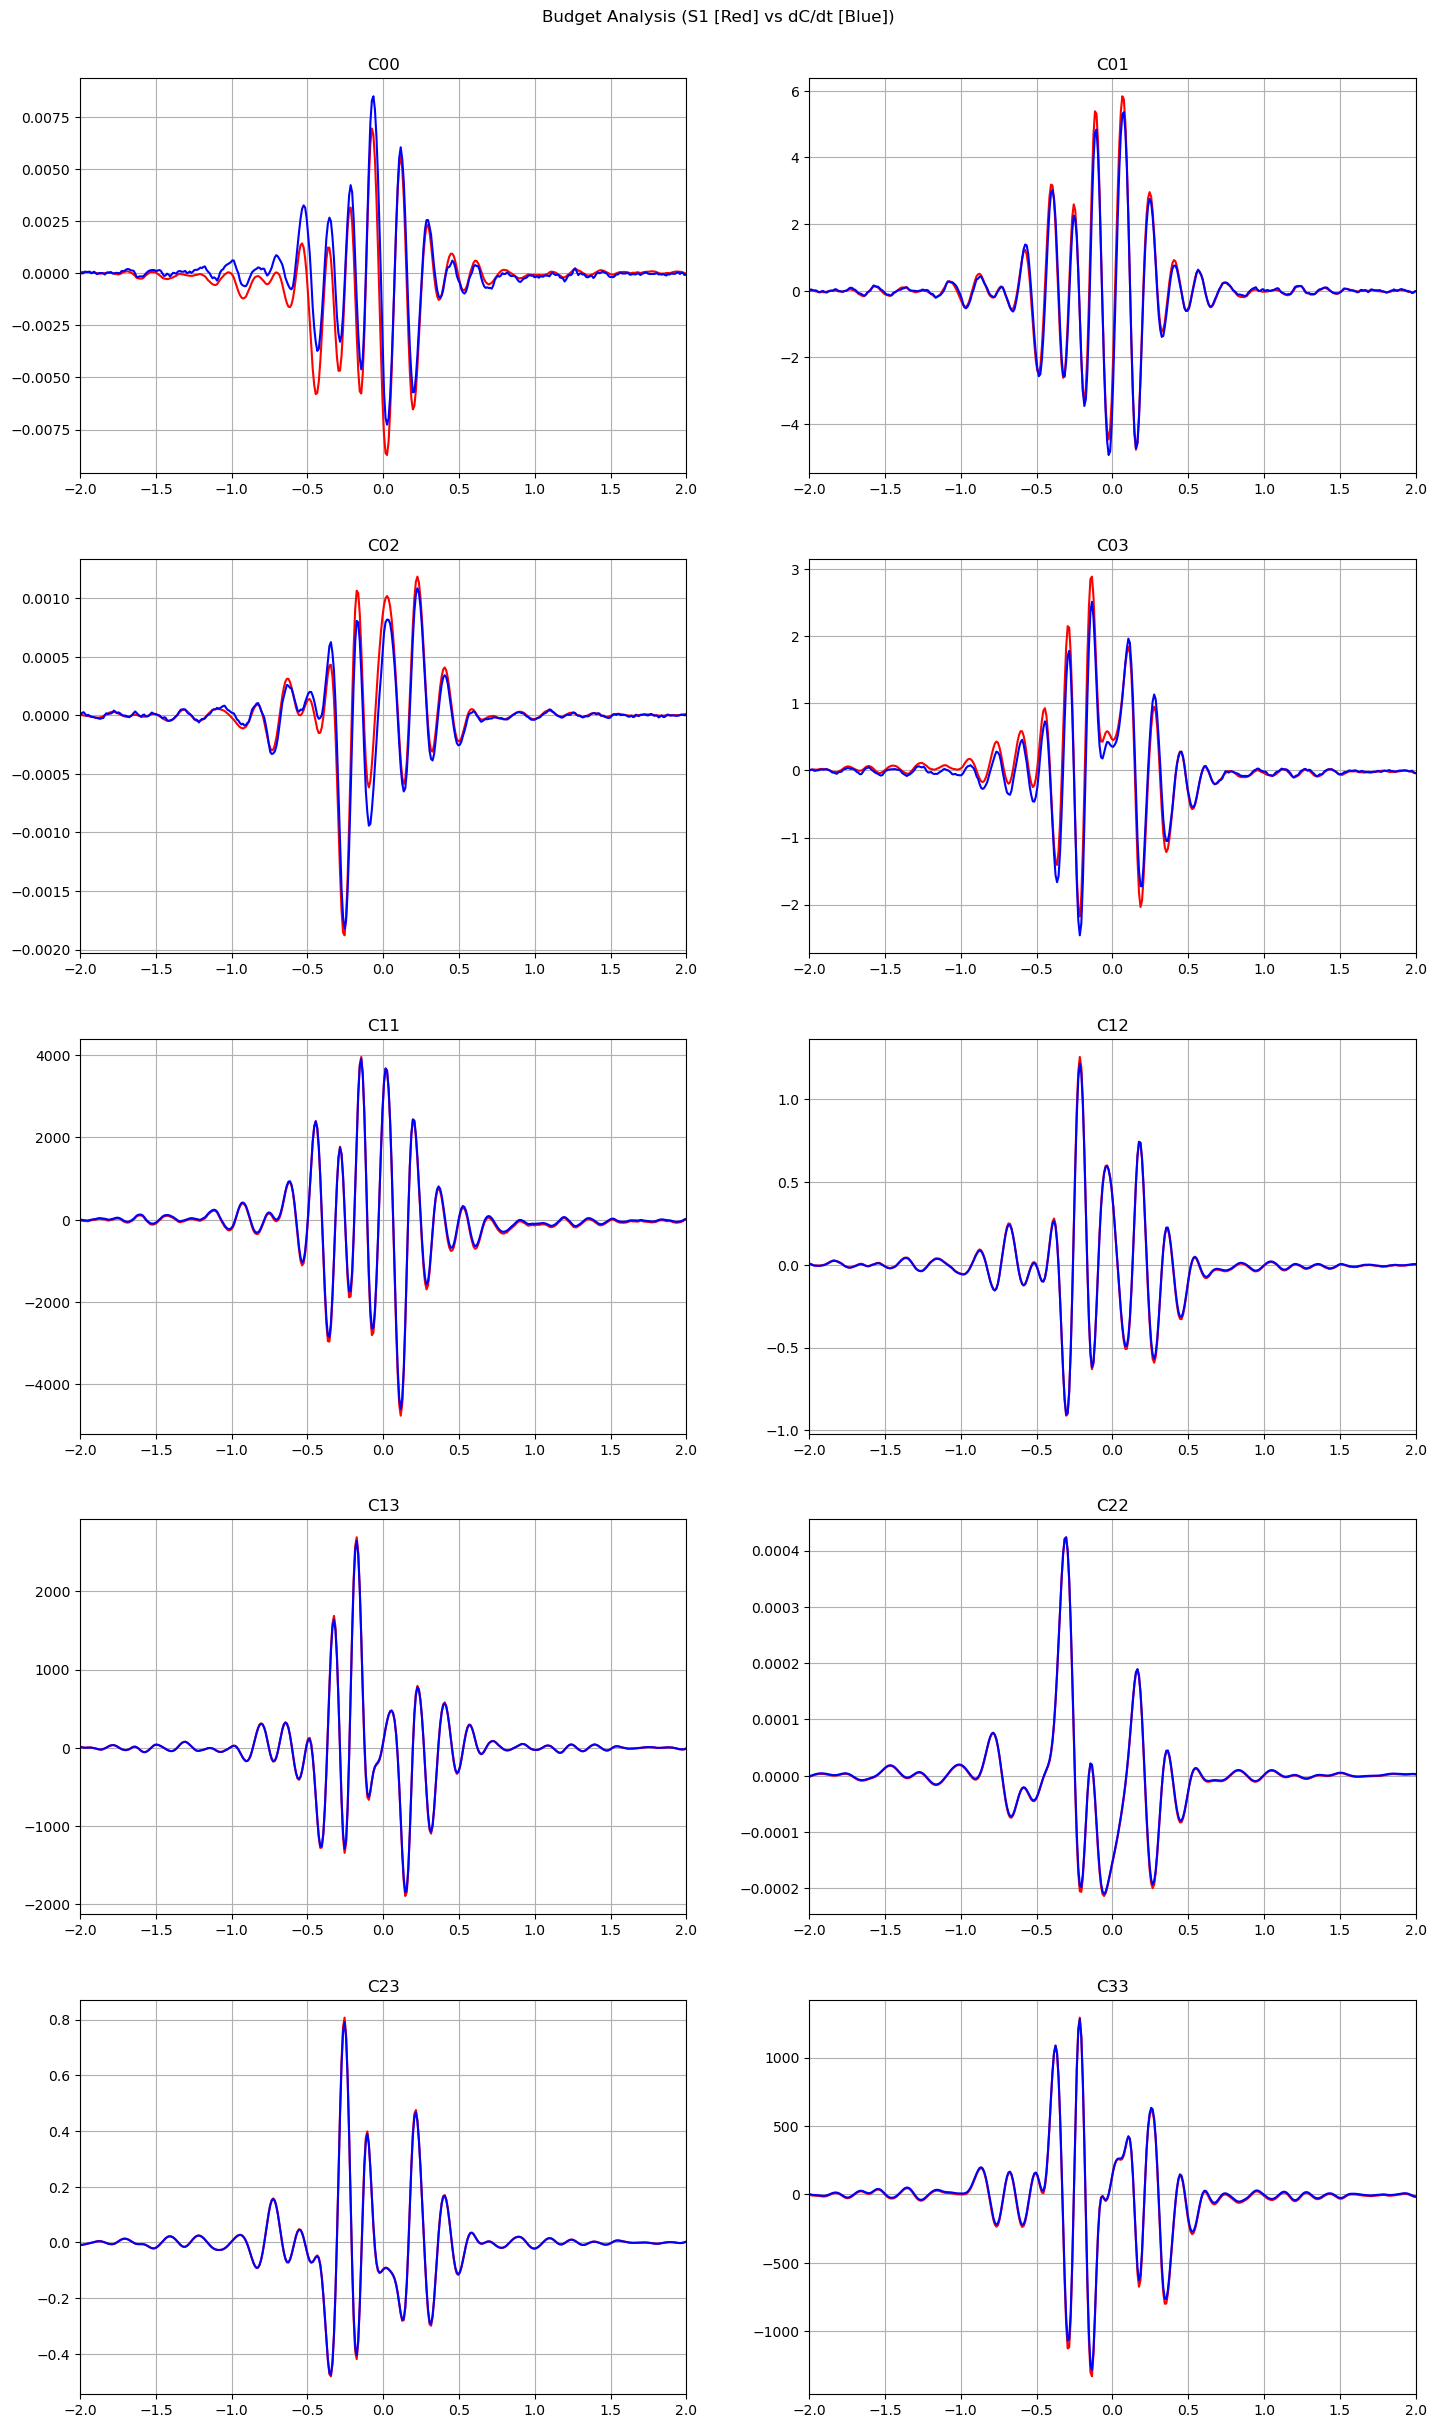

In [32]:
time_array = np.linspace(-5, 5,  int(10/.01))
# time_array = np.arange(2000/10, 2000/10) * dt * 10
#fig, axs = plt.subplots(1,1, figsize = (8, 12))
x_limit = (-2, 2)

fig, axs = plt.subplots(5, 2, figsize=(15, 25))


axs[0, 0].plot(time_array, s1[:, 0, 0],'r')
axs[0, 0].plot(time_array, dC_dt[:, 0, 0],'b')
axs[0, 0].set_title(f'C00')
axs[0, 0].set_xlim(x_limit)
axs[0, 0].grid()

axs[0, 1].plot(time_array, s1[:, 0, 1],'r')
axs[0, 1].plot(time_array, dC_dt[:, 0, 1],'b')
axs[0, 1].set_title(f'C01')
axs[0, 1].set_xlim(x_limit)
axs[0, 1].grid()

axs[1, 0].plot(time_array, s1[:, 0, 2],'r')
axs[1, 0].plot(time_array, dC_dt[:, 0, 2],'b')
axs[1, 0].set_title(f'C02')
axs[1, 0].set_xlim(x_limit)
axs[1, 0].grid()

axs[1, 1].plot(time_array, s1[:, 0, 3],'r')
axs[1, 1].plot(time_array, dC_dt[:, 0, 3],'b')
axs[1, 1].set_title(f'C03')
axs[1, 1].set_xlim(x_limit)
axs[1, 1].grid()

axs[2, 0].plot(time_array, s1[:, 1, 1],'r')
axs[2, 0].plot(time_array, dC_dt[:, 1, 1],'b')
axs[2, 0].set_title(f'C11')
axs[2, 0].set_xlim(x_limit)
axs[2, 0].grid()

axs[2, 1].plot(time_array, s1[:, 1, 2],'r')
axs[2, 1].plot(time_array, dC_dt[:, 1, 2],'b')
axs[2, 1].set_title(f'C12')
axs[2, 1].set_xlim(x_limit)
axs[2, 1].grid()

axs[3, 0].plot(time_array, s1[:, 1, 3],'r')
axs[3, 0].plot(time_array, dC_dt[:, 1, 3],'b')
axs[3, 0].set_title(f'C13')
axs[3, 0].set_xlim(x_limit)
axs[3, 0].grid()

axs[3, 1].plot(time_array, s1[:, 2, 2],'r')
axs[3, 1].plot(time_array, dC_dt[:, 2, 2],'b')
axs[3, 1].set_title(f'C22')
axs[3, 1].set_xlim(x_limit)
axs[3, 1].grid()

axs[4, 0].plot(time_array, s1[:, 2, 3],'r')
axs[4, 0].plot(time_array, dC_dt[:, 2, 3],'b')
axs[4, 0].set_title(f'C23')
axs[4, 0].set_xlim(x_limit)
axs[4, 0].grid()

axs[4, 1].plot(time_array, s1[:, 3, 3],'r')
axs[4, 1].plot(time_array, dC_dt[:, 3, 3],'b')
axs[4, 1].set_title(f'C33')
axs[4, 1].set_xlim(x_limit)
axs[4, 1].grid()


plt.suptitle(f"Budget Analysis (S1 [Red] vs dC/dt [Blue])")



#plt.subplots_adjust(wspace=.4)
#plt.subplots_adjust(hspace=.4)
plt.tight_layout(pad = 3)
plt.show()

In [33]:
#W<C> term
W_C = np.array([bigW @ C for C in average_C_Matrix])
W_C

array([[[-1.92096575e-04,  1.19044837e+00,  5.29698098e-05,
         -9.38975154e-02],
        [-1.10928458e+00,  4.44799050e-01, -3.05532073e-02,
          1.65557732e+02],
        [ 9.14271711e-05,  3.28812913e-02,  7.07206042e-08,
         -1.32966564e-01],
        [ 4.12995703e-02,  3.63768798e+01,  1.17521718e-01,
         -3.57953311e+01]],

       [[-1.98349682e-04,  1.18269723e+00,  5.02251826e-05,
         -9.11157783e-02],
        [-1.10896528e+00,  4.36731434e+00, -3.24656593e-02,
          1.62870973e+02],
        [ 8.97710120e-05,  3.20121564e-02,  5.17141634e-07,
         -1.32580302e-01],
        [ 4.31216145e-02,  3.47769033e+01,  1.17644218e-01,
         -3.65220400e+01]],

       [[-2.05318010e-04,  1.17634692e+00,  4.77412014e-05,
         -8.90363197e-02],
        [-1.10353684e+00,  8.86973113e+00, -3.03658090e-02,
          1.61065267e+02],
        [ 8.89417134e-05,  3.14020753e-02,  8.26969527e-07,
         -1.31955848e-01],
        [ 4.10050542e-02,  3.31720670e+

In [34]:
#<C>W^T
CW_T = np.array([C @ bigW.T for C in average_C_Matrix])
CW_T

array([[[-1.92096575e-04, -1.10928458e+00,  9.14271711e-05,
          4.12995703e-02],
        [ 1.19044837e+00,  4.44799050e-01,  3.28812913e-02,
          3.63768798e+01],
        [ 5.29698098e-05, -3.05532073e-02,  7.07206042e-08,
          1.17521718e-01],
        [-9.38975154e-02,  1.65557732e+02, -1.32966564e-01,
         -3.57953311e+01]],

       [[-1.98349682e-04, -1.10896528e+00,  8.97710120e-05,
          4.31216145e-02],
        [ 1.18269723e+00,  4.36731434e+00,  3.20121564e-02,
          3.47769033e+01],
        [ 5.02251826e-05, -3.24656593e-02,  5.17141634e-07,
          1.17644218e-01],
        [-9.11157783e-02,  1.62870973e+02, -1.32580302e-01,
         -3.65220400e+01]],

       [[-2.05318010e-04, -1.10353684e+00,  8.89417134e-05,
          4.10050542e-02],
        [ 1.17634692e+00,  8.86973113e+00,  3.14020753e-02,
          3.31720670e+01],
        [ 4.77412014e-05, -3.03658090e-02,  8.26969527e-07,
          1.17838765e-01],
        [-8.90363197e-02,  1.61065267e+

In [35]:
U = np.mean(average_U)
U

0.021990040657444043

In [36]:
#<U>L<C>
result_ULC = np.array([U * (bigL @ C) for C in average_C_Matrix])
result_ULC

array([[[-1.86311773e-06, -2.08813561e-03, -7.74217628e-06,
          1.11070335e-03],
        [-5.53446448e-03, -2.09490286e+00, -5.74501731e-04,
          7.93123193e+00],
        [-1.12975711e-06,  5.71207644e-05, -2.83435759e-08,
          1.62778367e-04],
        [ 1.94210599e-03, -2.31614730e+01, -1.08007014e-03,
          2.09490286e+00]],

       [[-1.99870191e-06, -1.99087746e-03, -7.74605826e-06,
          1.16220643e-03],
        [-5.44668429e-03, -2.03643073e+00, -6.01141258e-04,
          7.91222373e+00],
        [-1.12973223e-06,  6.07143416e-05, -3.04062157e-08,
          1.60196597e-04],
        [ 2.06428762e-03, -2.30043125e+01, -1.02976421e-03,
          2.03643073e+00]],

       [[-1.86703520e-06, -1.89086839e-03, -7.75596866e-06,
          1.19897865e-03],
        [-5.38802910e-03, -1.99304867e+00, -6.20161370e-04,
          7.87806914e+00],
        [-1.12458008e-06,  6.49604289e-05, -2.84031725e-08,
          1.58471444e-04],
        [ 2.20865458e-03, -2.28734690e+

In [37]:
#<U><C>L^T 
result_UCLT = np.array([U * (C @ bigL.T) for C in average_C_Matrix])
result_UCLT

array([[[-1.86311773e-06, -5.53446448e-03, -1.12975711e-06,
          1.94210599e-03],
        [-2.08813561e-03, -2.09490286e+00,  5.71207644e-05,
         -2.31614730e+01],
        [-7.74217628e-06, -5.74501731e-04, -2.83435759e-08,
         -1.08007014e-03],
        [ 1.11070335e-03,  7.93123193e+00,  1.62778367e-04,
          2.09490286e+00]],

       [[-1.99870191e-06, -5.44668429e-03, -1.12973223e-06,
          2.06428762e-03],
        [-1.99087746e-03, -2.03643073e+00,  6.07143416e-05,
         -2.30043125e+01],
        [-7.74605826e-06, -6.01141258e-04, -3.04062157e-08,
         -1.02976421e-03],
        [ 1.16220643e-03,  7.91222373e+00,  1.60196597e-04,
          2.03643073e+00]],

       [[-1.86703520e-06, -5.38802910e-03, -1.12458008e-06,
          2.20865458e-03],
        [-1.89086839e-03, -1.99304867e+00,  6.49604289e-05,
         -2.28734690e+01],
        [-7.75596866e-06, -6.20161370e-04, -2.84031725e-08,
         -9.78035374e-04],
        [ 1.19897865e-03,  7.87806914e+

In [38]:
s2 = W_C + CW_T + result_ULC + result_UCLT + epsilon*bigQ
s2

array([[[ 1.70214896e-04,  7.35411898e-02,  1.35525048e-04,
         -4.95451358e-02],
        [ 7.35411898e-02, -3.30020763e+00,  1.81070302e-03,
          1.86704371e+02],
        [ 1.35525048e-04,  1.81070302e-03,  8.47540566e-08,
         -1.63621372e-02],
        [-4.95451358e-02,  1.86704371e+02, -1.63621372e-02,
         -6.74008565e+01]],

       [[ 1.57437514e-04,  6.62943939e-02,  1.31120404e-04,
         -4.47676698e-02],
        [ 6.62943939e-02,  4.66176723e+00, -9.93929758e-04,
          1.82555788e+02],
        [ 1.31120404e-04, -9.93929758e-04,  9.73470836e-07,
         -1.58056516e-02],
        [-4.47676698e-02,  1.82555788e+02, -1.58056516e-02,
         -6.89712185e+01]],

       [[ 1.43764191e-04,  6.55311903e-02,  1.27802366e-04,
         -4.46236323e-02],
        [ 6.55311903e-02,  1.37533649e+01,  4.81065389e-04,
          1.79241934e+02],
        [ 1.27802366e-04,  4.81065389e-04,  1.59713271e-06,
         -1.49366467e-02],
        [-4.46236323e-02,  1.79241934e+

In [39]:
diff = s1 - s2
diff

array([[[-5.59805409e-05, -9.42467524e-02, -1.36121510e-04,
          5.01104398e-02],
        [-9.42467524e-02, -6.08870095e+01, -1.04322437e-02,
         -1.70220808e+02],
        [-1.36121510e-04, -1.04322437e-02, -8.51630947e-07,
          9.40543545e-03],
        [ 5.01104398e-02, -1.70220808e+02,  9.40543545e-03,
          6.08870095e+01]],

       [[-6.35697461e-05, -9.06491003e-02, -1.37226293e-04,
          5.37339100e-02],
        [-9.06491003e-02, -5.82727410e+01, -1.08951450e-02,
         -1.69040567e+02],
        [-1.37226293e-04, -1.08951450e-02, -9.67085386e-07,
          1.04340490e-02],
        [ 5.37339100e-02, -1.69040567e+02,  1.04340490e-02,
          5.82727410e+01]],

       [[-6.28688397e-05, -8.65510929e-02, -1.38303496e-04,
          5.76562660e-02],
        [-8.65510929e-02, -5.63390226e+01, -1.10955472e-02,
         -1.68738652e+02],
        [-1.38303496e-04, -1.10955472e-02, -9.56422511e-07,
          1.16440239e-02],
        [ 5.76562660e-02, -1.68738652e+

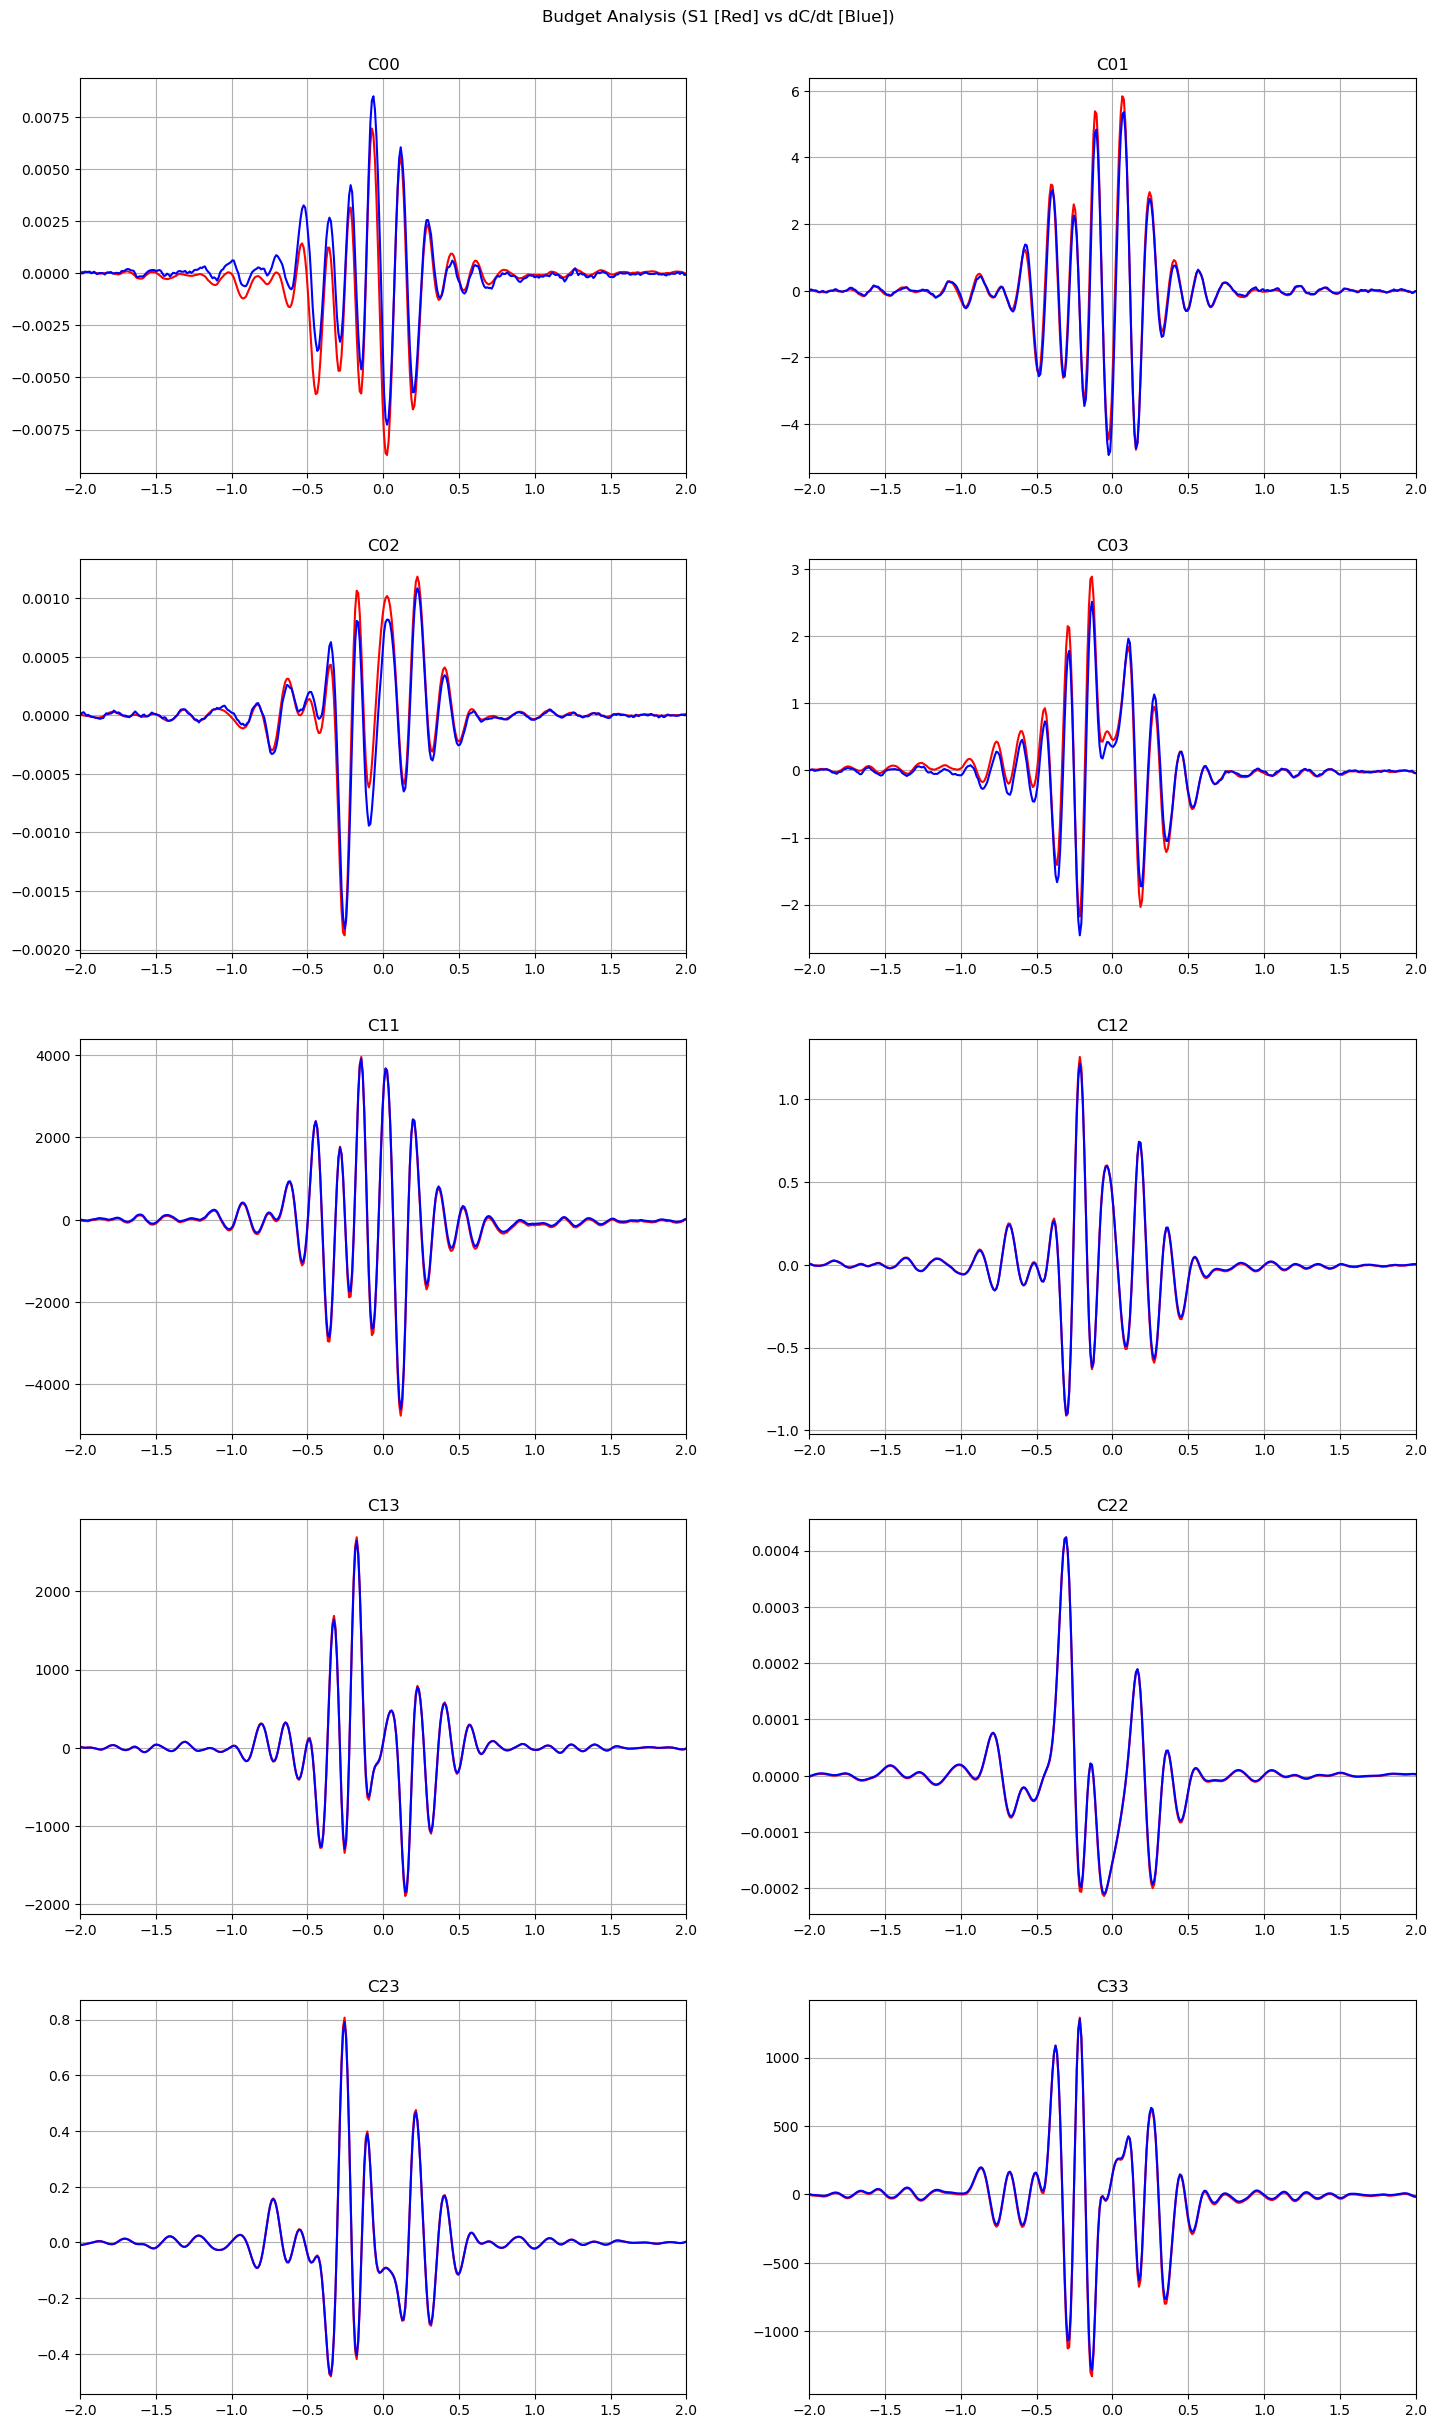

In [40]:
time_array = np.linspace(-5, 5, int(10/.01))
# time_array = np.arange(2000/10, 2000/10) * dt * 10
#fig, axs = plt.subplots(1,1, figsize = (8, 12))
x_limit = (-2, 2)

fig, axs = plt.subplots(5, 2, figsize=(15, 25))


axs[0, 0].plot(time_array, s1[:, 0, 0],'r')
axs[0, 0].plot(time_array, dC_dt[:, 0, 0],'b')
axs[0, 0].set_title(f'C00')
axs[0, 0].set_xlim(x_limit)
axs[0, 0].grid()

axs[0, 1].plot(time_array, s1[:, 0, 1],'r')
axs[0, 1].plot(time_array, dC_dt[:, 0, 1],'b')
axs[0, 1].set_title(f'C01')
axs[0, 1].set_xlim(x_limit)
axs[0, 1].grid()

axs[1, 0].plot(time_array, s1[:, 0, 2],'r')
axs[1, 0].plot(time_array, dC_dt[:, 0, 2],'b')
axs[1, 0].set_title(f'C02')
axs[1, 0].set_xlim(x_limit)
axs[1, 0].grid()

axs[1, 1].plot(time_array, s1[:, 0, 3],'r')
axs[1, 1].plot(time_array, dC_dt[:, 0, 3],'b')
axs[1, 1].set_title(f'C03')
axs[1, 1].set_xlim(x_limit)
axs[1, 1].grid()

axs[2, 0].plot(time_array, s1[:, 1, 1],'r')
axs[2, 0].plot(time_array, dC_dt[:, 1, 1],'b')
axs[2, 0].set_title(f'C11')
axs[2, 0].set_xlim(x_limit)
axs[2, 0].grid()

axs[2, 1].plot(time_array, s1[:, 1, 2],'r')
axs[2, 1].plot(time_array, dC_dt[:, 1, 2],'b')
axs[2, 1].set_title(f'C12')
axs[2, 1].set_xlim(x_limit)
axs[2, 1].grid()

axs[3, 0].plot(time_array, s1[:, 1, 3],'r')
axs[3, 0].plot(time_array, dC_dt[:, 1, 3],'b')
axs[3, 0].set_title(f'C13')
axs[3, 0].set_xlim(x_limit)
axs[3, 0].grid()

axs[3, 1].plot(time_array, s1[:, 2, 2],'r')
axs[3, 1].plot(time_array, dC_dt[:, 2, 2],'b')
axs[3, 1].set_title(f'C22')
axs[3, 1].set_xlim(x_limit)
axs[3, 1].grid()

axs[4, 0].plot(time_array, s1[:, 2, 3],'r')
axs[4, 0].plot(time_array, dC_dt[:, 2, 3],'b')
axs[4, 0].set_title(f'C23')
axs[4, 0].set_xlim(x_limit)
axs[4, 0].grid()

axs[4, 1].plot(time_array, s1[:, 3, 3],'r')
axs[4, 1].plot(time_array, dC_dt[:, 3, 3],'b')
axs[4, 1].set_title(f'C33')
axs[4, 1].set_xlim(x_limit)
axs[4, 1].grid()


plt.suptitle(f"Budget Analysis (S1 [Red] vs dC/dt [Blue])")



#plt.subplots_adjust(wspace=.4)
#plt.subplots_adjust(hspace=.4)
plt.tight_layout(pad = 3)
plt.show()

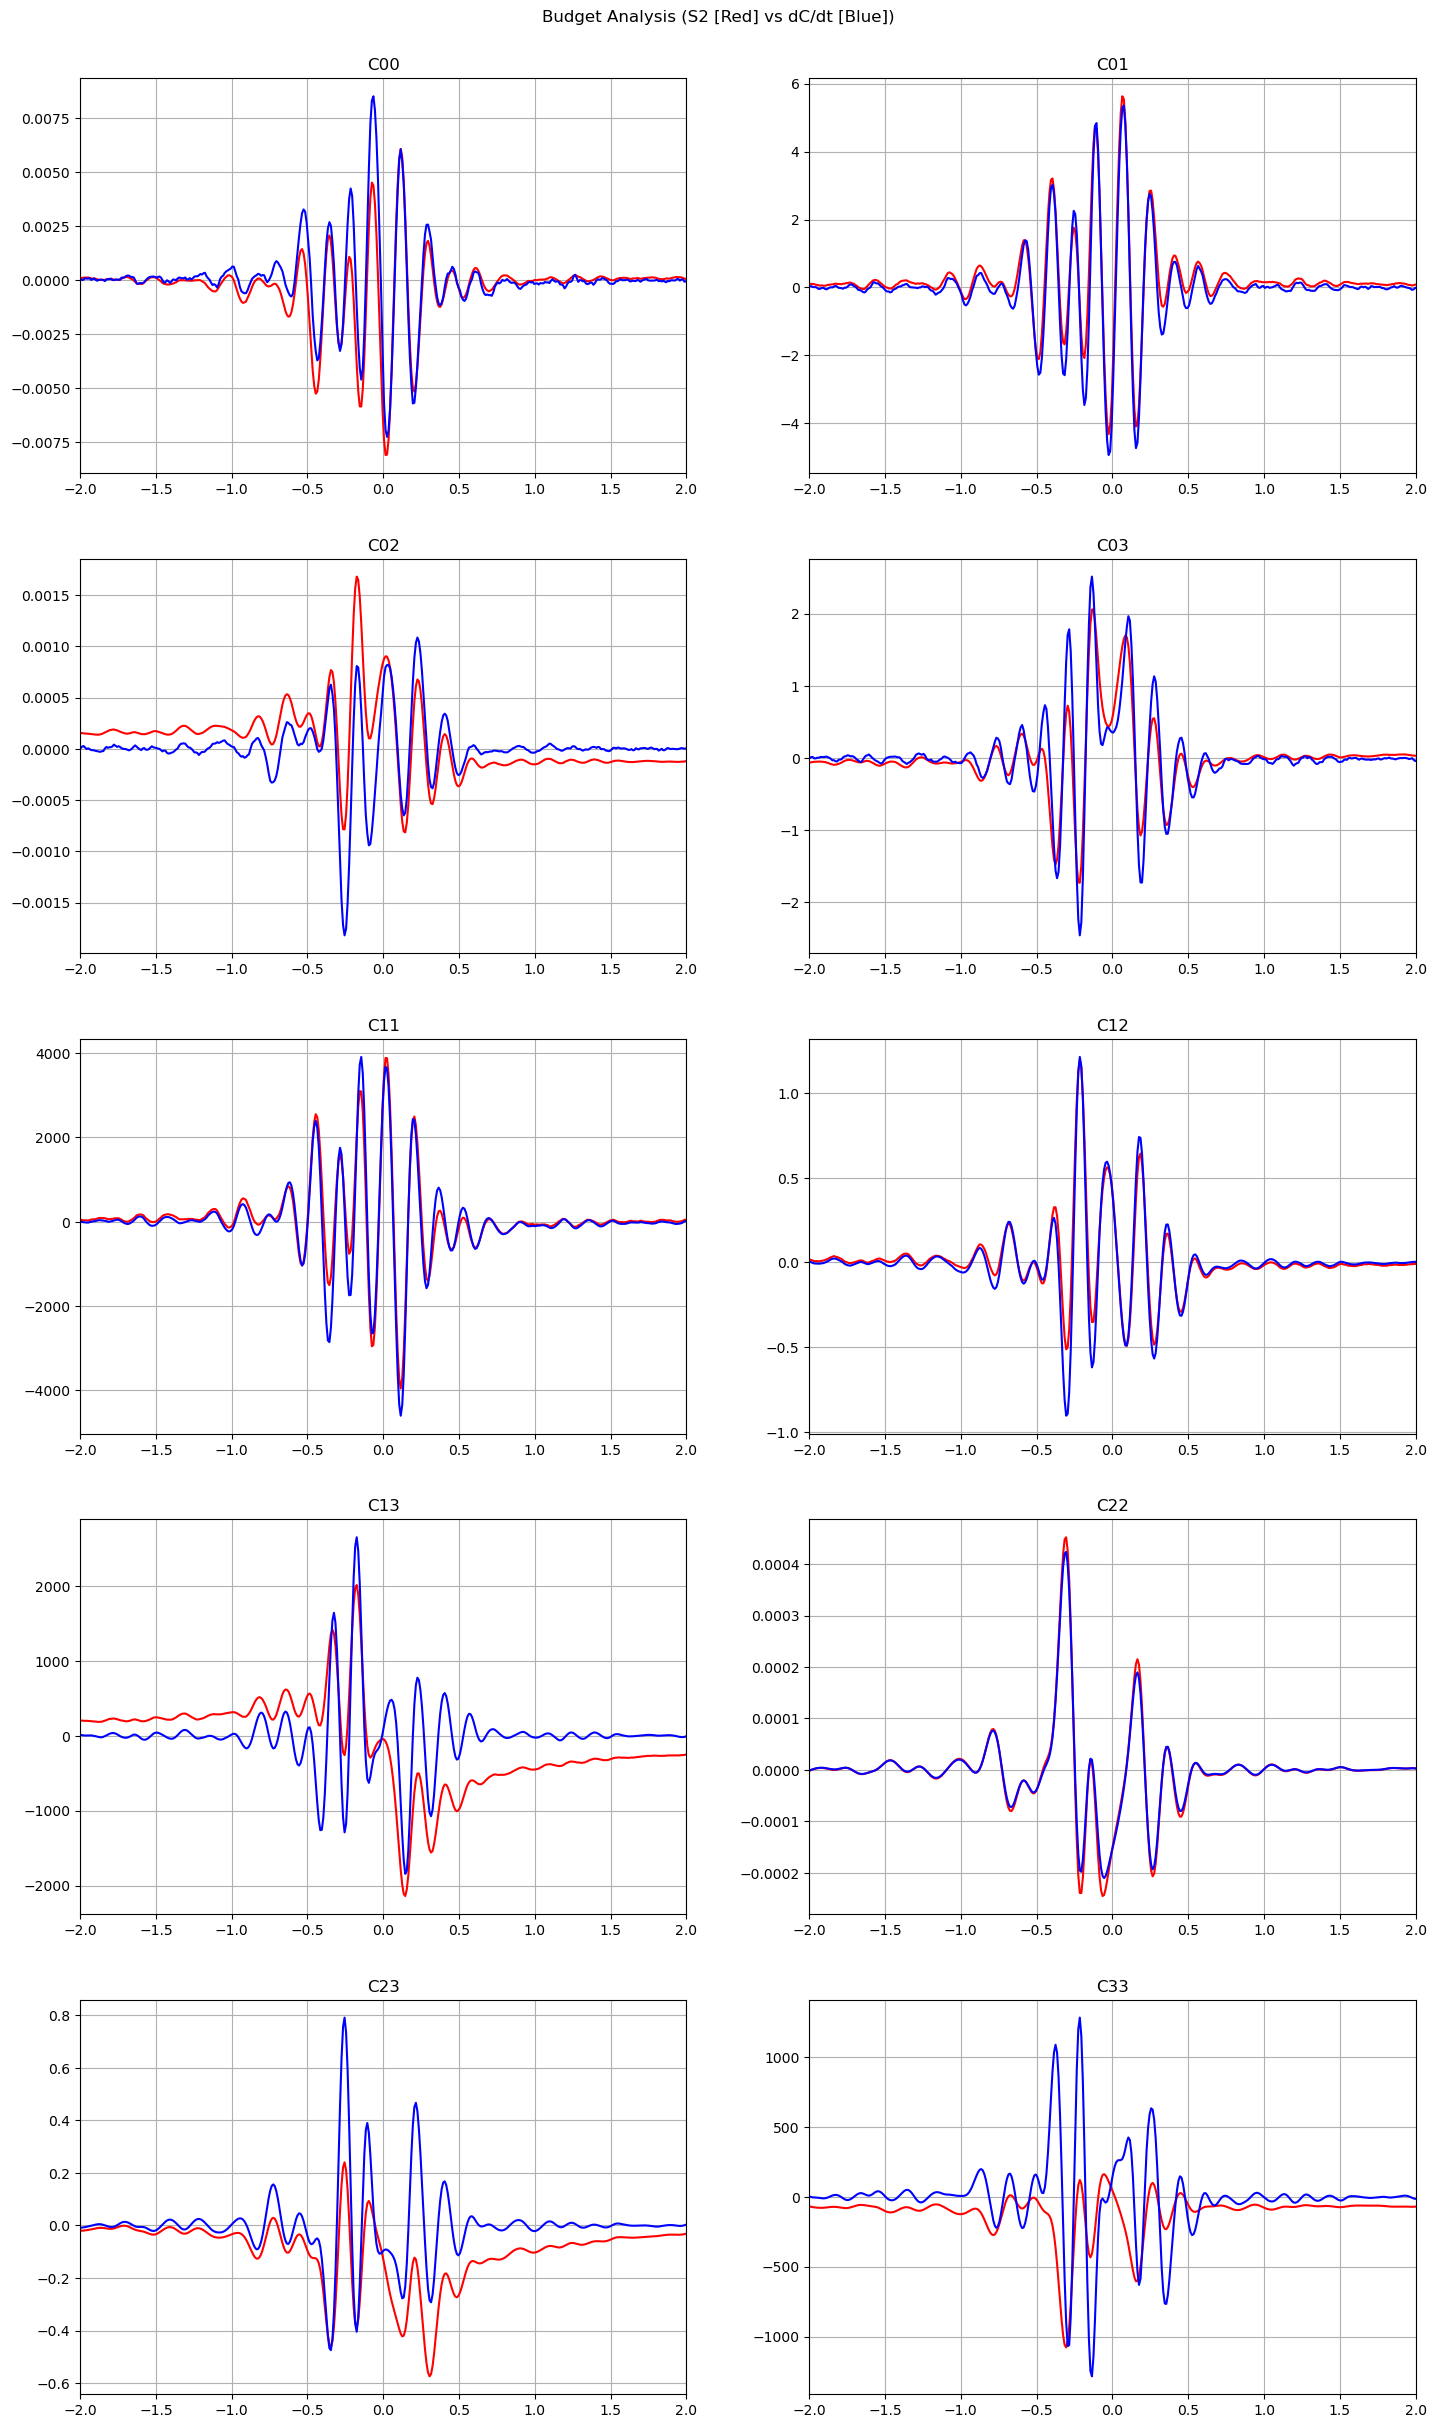

In [41]:
time_array = np.linspace(-5, 5, int(10/.01))
# time_array = np.arange(2000/10, 2000/10) * dt * 10
#fig, axs = plt.subplots(1,1, figsize = (8, 12))
x_limit = (-2, 2)

fig, axs = plt.subplots(5, 2, figsize=(15, 25))


axs[0, 0].plot(time_array, s2[:, 0, 0],'r')
axs[0, 0].plot(time_array, dC_dt[:, 0, 0],'b')
axs[0, 0].set_title(f'C00')
axs[0, 0].set_xlim(x_limit)
axs[0, 0].grid()

axs[0, 1].plot(time_array, s2[:, 0, 1],'r')
axs[0, 1].plot(time_array, dC_dt[:, 0, 1],'b')
axs[0, 1].set_title(f'C01')
axs[0, 1].set_xlim(x_limit)
axs[0, 1].grid()

axs[1, 0].plot(time_array, s2[:, 0, 2],'r')
axs[1, 0].plot(time_array, dC_dt[:, 0, 2],'b')
axs[1, 0].set_title(f'C02')
axs[1, 0].set_xlim(x_limit)
axs[1, 0].grid()

axs[1, 1].plot(time_array, s2[:, 0, 3],'r')
axs[1, 1].plot(time_array, dC_dt[:, 0, 3],'b')
axs[1, 1].set_title(f'C03')
axs[1, 1].set_xlim(x_limit)
axs[1, 1].grid()

axs[2, 0].plot(time_array, s2[:, 1, 1],'r')
axs[2, 0].plot(time_array, dC_dt[:, 1, 1],'b')
axs[2, 0].set_title(f'C11')
axs[2, 0].set_xlim(x_limit)
axs[2, 0].grid()

axs[2, 1].plot(time_array, s2[:, 1, 2],'r')
axs[2, 1].plot(time_array, dC_dt[:, 1, 2],'b')
axs[2, 1].set_title(f'C12')
axs[2, 1].set_xlim(x_limit)
axs[2, 1].grid()

axs[3, 0].plot(time_array, s2[:, 1, 3],'r')
axs[3, 0].plot(time_array, dC_dt[:, 1, 3],'b')
axs[3, 0].set_title(f'C13')
axs[3, 0].set_xlim(x_limit)
axs[3, 0].grid()

axs[3, 1].plot(time_array, s2[:, 2, 2],'r')
axs[3, 1].plot(time_array, dC_dt[:, 2, 2],'b')
axs[3, 1].set_title(f'C22')
axs[3, 1].set_xlim(x_limit)
axs[3, 1].grid()

axs[4, 0].plot(time_array, s2[:, 2, 3],'r')
axs[4, 0].plot(time_array, dC_dt[:, 2, 3],'b')
axs[4, 0].set_title(f'C23')
axs[4, 0].set_xlim(x_limit)
axs[4, 0].grid()

axs[4, 1].plot(time_array, s2[:, 3, 3],'r')
axs[4, 1].plot(time_array, dC_dt[:, 3, 3],'b')
axs[4, 1].set_title(f'C33')
axs[4, 1].set_xlim(x_limit)
axs[4, 1].grid()


plt.suptitle(f"Budget Analysis (S2 [Red] vs dC/dt [Blue])")



#plt.subplots_adjust(wspace=.4)
#plt.subplots_adjust(hspace=.4)
plt.tight_layout(pad = 3)
plt.show()

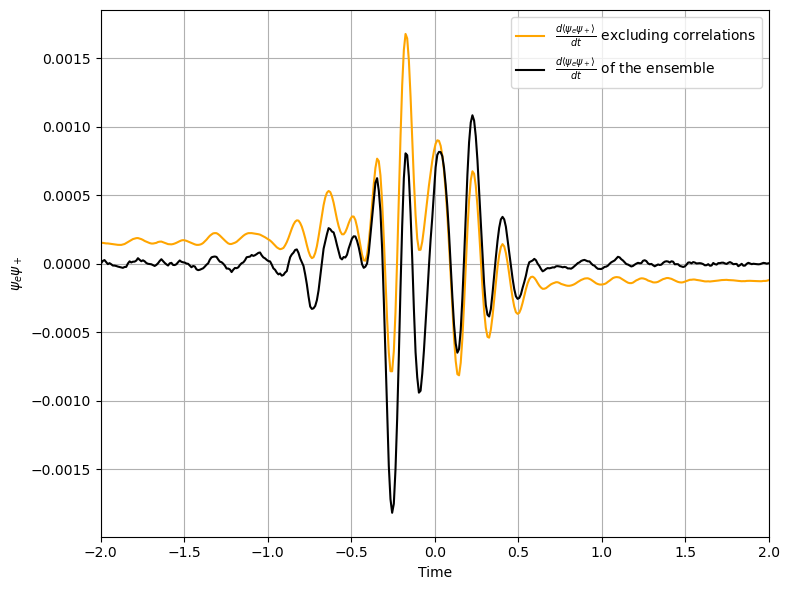

In [42]:
time_array = np.linspace(-5, 5, int(10/.01))
x_limit = (-2, 2)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))

# Plotting with LaTeX legend labels
axs.plot(time_array, s2[:, 0, 2], 'orange', label=r'$\frac{d\langle \psi_e \psi_+ \rangle}{dt}$ excluding correlations')
axs.plot(time_array, dC_dt[:, 0, 2], 'black', label=r'$\frac{d\langle \psi_e \psi_+ \rangle}{dt}$ of the ensemble')

axs.set_xlabel('Time')
axs.set_ylabel(r'$\psi_e \psi_+$')
axs.set_xlim(x_limit)
axs.grid()

# Add the legend
axs.legend()

plt.tight_layout()
plt.show()

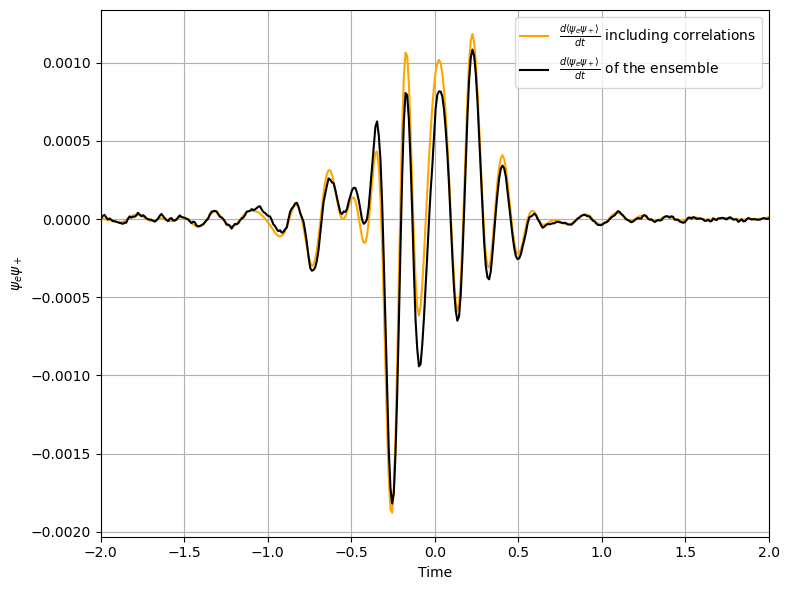

In [43]:
time_array = np.linspace(-5, 5, int(10/.01))
x_limit = (-2, 2)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))

# Plotting with LaTeX legend labels
axs.plot(time_array, s1[:, 0, 2], 'orange', label=r'$\frac{d\langle \psi_e \psi_+ \rangle}{dt}$ including correlations')
axs.plot(time_array, dC_dt[:, 0, 2], 'black', label=r'$\frac{d\langle \psi_e \psi_+ \rangle}{dt}$ of the ensemble')

axs.set_xlabel('Time')
axs.set_ylabel(r'$\psi_e \psi_+$')
axs.set_xlim(x_limit)
axs.grid()

# Add the legend
axs.legend()

plt.tight_layout()
plt.show()

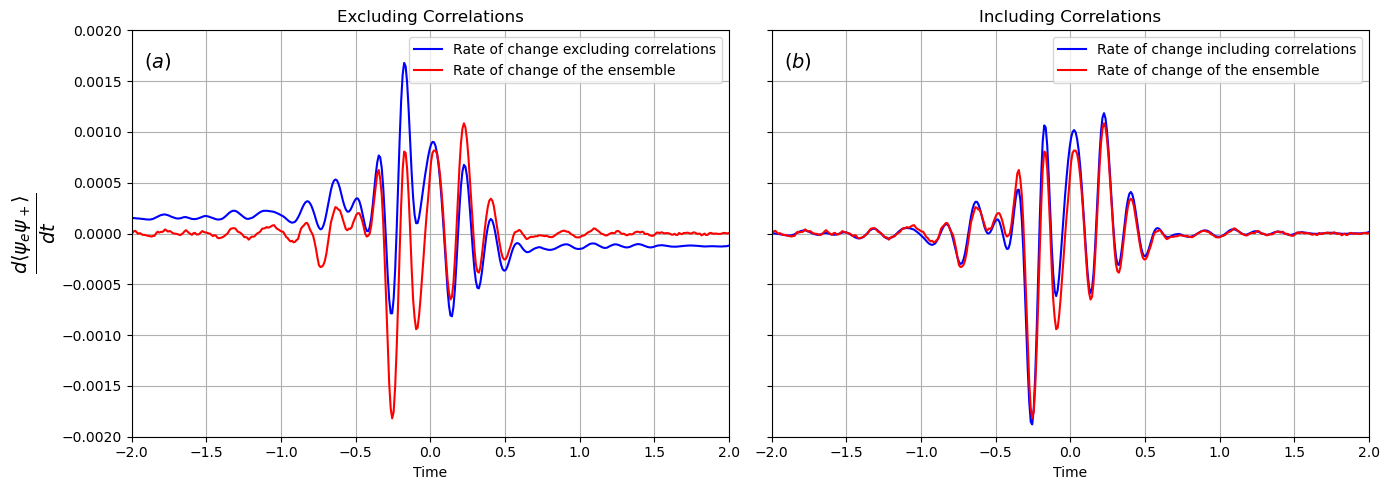

In [44]:
import numpy as np
import matplotlib.pyplot as plt

time_array = np.linspace(-5, 5, int(10 / 0.01))
x_limit = (-2, 2)
y_limit = (-0.002, 0.002)

fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# ---------- Left panel: Excluding Correlations ----------
ax = axs[0]
# ax.plot(time_array, s2[:, 0, 2], 'orange',
#         label=r'$\frac{d\langle \psi_e \psi_+ \rangle}{dt}$ excluding correlations')
# ax.plot(time_array, dC_dt[:, 0, 2], 'black',
#         label=r'$\frac{d\langle \psi_e \psi_+ \rangle}{dt}$ of the ensemble')
ax.plot(time_array, s2[:, 0, 2], 'blue',
        label=r'Rate of change excluding correlations')
ax.plot(time_array, dC_dt[:, 0, 2], 'red',
        label=r'Rate of change of the ensemble')

ax.set_xlabel('Time')
ax.set_ylabel(
    r'$\frac{d\langle \psi_e \psi_+ \rangle}{dt}$',
#     rotation=360,
    va='center',
    labelpad=20,
    fontsize=20
)

ax.set_xlim(x_limit)
ax.set_ylim(y_limit)
ax.grid()
ax.set_title('Excluding Correlations')
ax.legend()

# panel label (a) inside the axes
ax.text(0.02, 0.95, r'$(a)$',
        transform=ax.transAxes,
        fontsize=14,
        va='top', ha='left')

# ---------- Right panel: Including Correlations ----------
ax = axs[1]
# ax.plot(time_array, s1[:, 0, 2], 'blue',
#         label=r'$\frac{d\langle \psi_e \psi_+ \rangle}{dt}$ including correlations')
# ax.plot(time_array, dC_dt[:, 0, 2], 'red',
#         label=r'$\frac{d\langle \psi_e \psi_+ \rangle}{dt}$ of the ensemble')
ax.plot(time_array, s1[:, 0, 2], 'blue',
        label=r'Rate of change including correlations')
ax.plot(time_array, dC_dt[:, 0, 2], 'red',
        label=r'Rate of change of the ensemble')

ax.set_xlabel('Time')
ax.set_xlim(x_limit)
ax.set_ylim(y_limit)
ax.grid()
ax.set_title('Including Correlations')
ax.legend()

# panel label (b) inside the axes
ax.text(0.02, 0.95, r'$(b)$',
        transform=ax.transAxes,
        fontsize=14,
        va='top', ha='left')

plt.tight_layout()
plt.show()


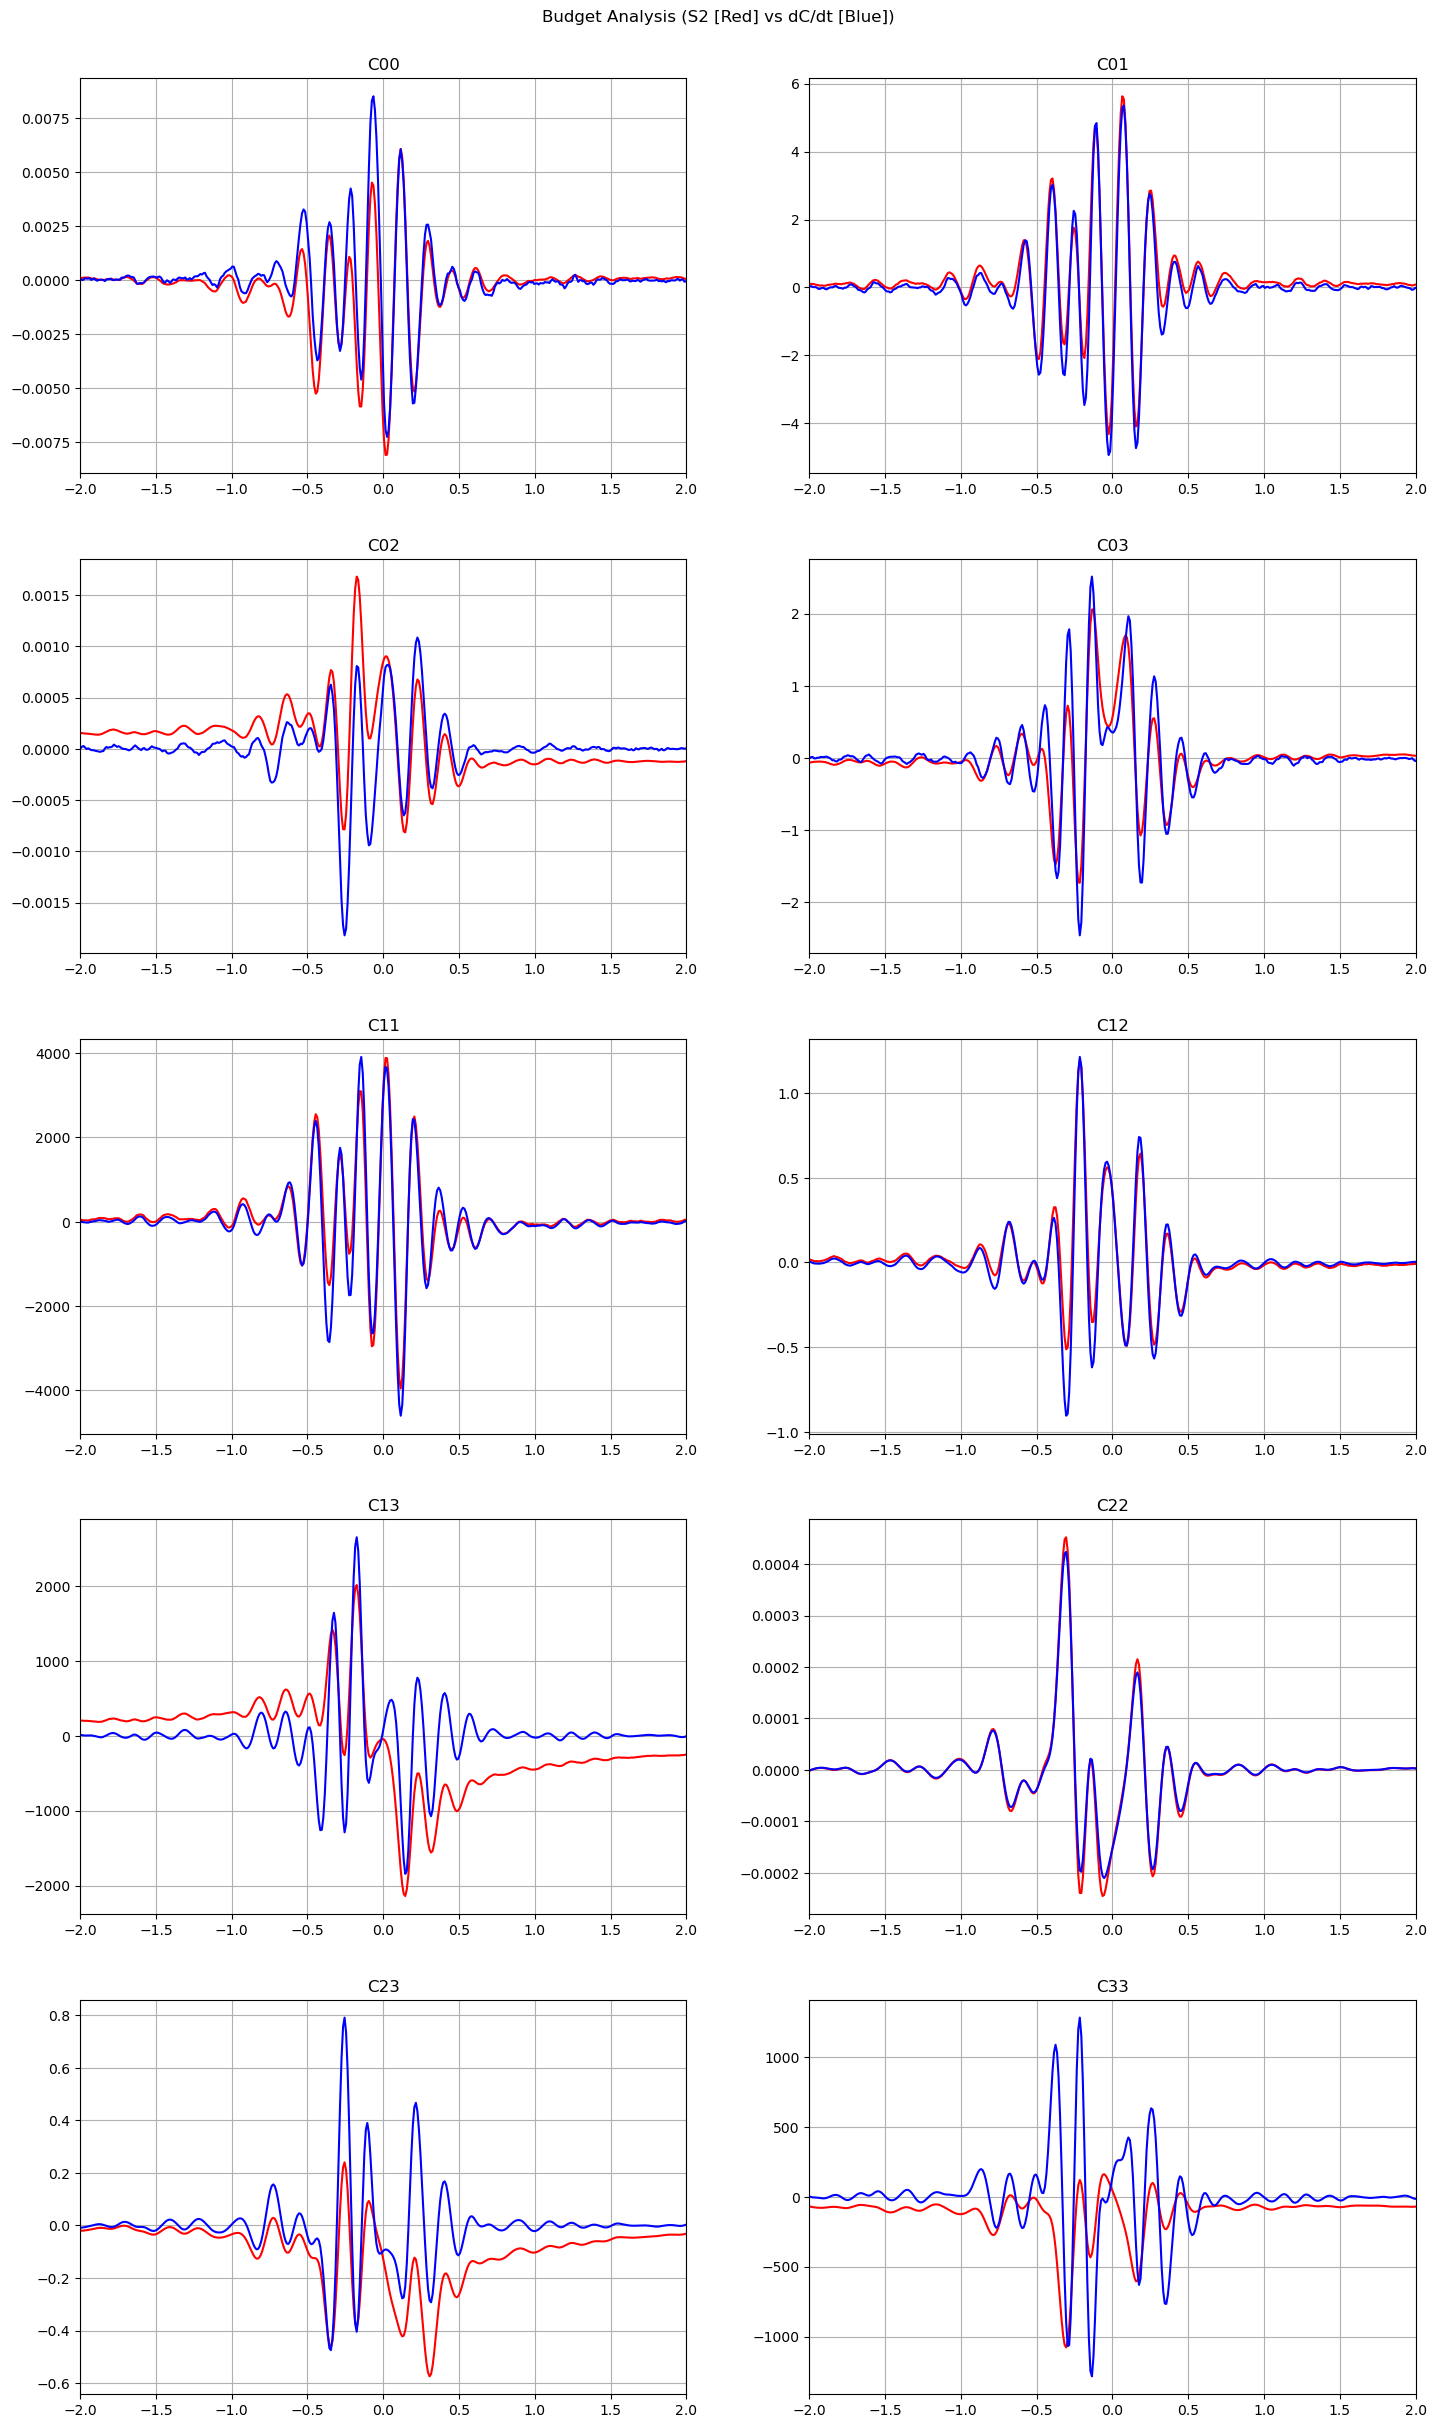

In [45]:
time_array = np.linspace(-5, 5, int(10/.01))
# time_array = np.arange(2000/10, 2000/10) * dt * 10
#fig, axs = plt.subplots(1,1, figsize = (8, 12))
x_limit = (-2, 2)

fig, axs = plt.subplots(5, 2, figsize=(15, 25))


axs[0, 0].plot(time_array, s2[:, 0, 0],'r')
axs[0, 0].plot(time_array, dC_dt[:, 0, 0],'b')
axs[0, 0].set_title(f'C00')
axs[0, 0].set_xlim(x_limit)
axs[0, 0].grid()

axs[0, 1].plot(time_array, s2[:, 0, 1],'r')
axs[0, 1].plot(time_array, dC_dt[:, 0, 1],'b')
axs[0, 1].set_title(f'C01')
axs[0, 1].set_xlim(x_limit)
axs[0, 1].grid()

axs[1, 0].plot(time_array, s2[:, 0, 2],'r')
axs[1, 0].plot(time_array, dC_dt[:, 0, 2],'b')
axs[1, 0].set_title(f'C02')
axs[1, 0].set_xlim(x_limit)
axs[1, 0].grid()

axs[1, 1].plot(time_array, s2[:, 0, 3],'r')
axs[1, 1].plot(time_array, dC_dt[:, 0, 3],'b')
axs[1, 1].set_title(f'C03')
axs[1, 1].set_xlim(x_limit)
axs[1, 1].grid()

axs[2, 0].plot(time_array, s2[:, 1, 1],'r')
axs[2, 0].plot(time_array, dC_dt[:, 1, 1],'b')
axs[2, 0].set_title(f'C11')
axs[2, 0].set_xlim(x_limit)
axs[2, 0].grid()

axs[2, 1].plot(time_array, s2[:, 1, 2],'r')
axs[2, 1].plot(time_array, dC_dt[:, 1, 2],'b')
axs[2, 1].set_title(f'C12')
axs[2, 1].set_xlim(x_limit)
axs[2, 1].grid()

axs[3, 0].plot(time_array, s2[:, 1, 3],'r')
axs[3, 0].plot(time_array, dC_dt[:, 1, 3],'b')
axs[3, 0].set_title(f'C13')
axs[3, 0].set_xlim(x_limit)
axs[3, 0].grid()

axs[3, 1].plot(time_array, s2[:, 2, 2],'r')
axs[3, 1].plot(time_array, dC_dt[:, 2, 2],'b')
axs[3, 1].set_title(f'C22')
axs[3, 1].set_xlim(x_limit)
axs[3, 1].grid()

axs[4, 0].plot(time_array, s2[:, 2, 3],'r')
axs[4, 0].plot(time_array, dC_dt[:, 2, 3],'b')
axs[4, 0].set_title(f'C23')
axs[4, 0].set_xlim(x_limit)
axs[4, 0].grid()

axs[4, 1].plot(time_array, s2[:, 3, 3],'r')
axs[4, 1].plot(time_array, dC_dt[:, 3, 3],'b')
axs[4, 1].set_title(f'C33')
axs[4, 1].set_xlim(x_limit)
axs[4, 1].grid()


plt.suptitle(f"Budget Analysis (S2 [Red] vs dC/dt [Blue])")



#plt.subplots_adjust(wspace=.4)
#plt.subplots_adjust(hspace=.4)
plt.tight_layout(pad = 3)
plt.show()

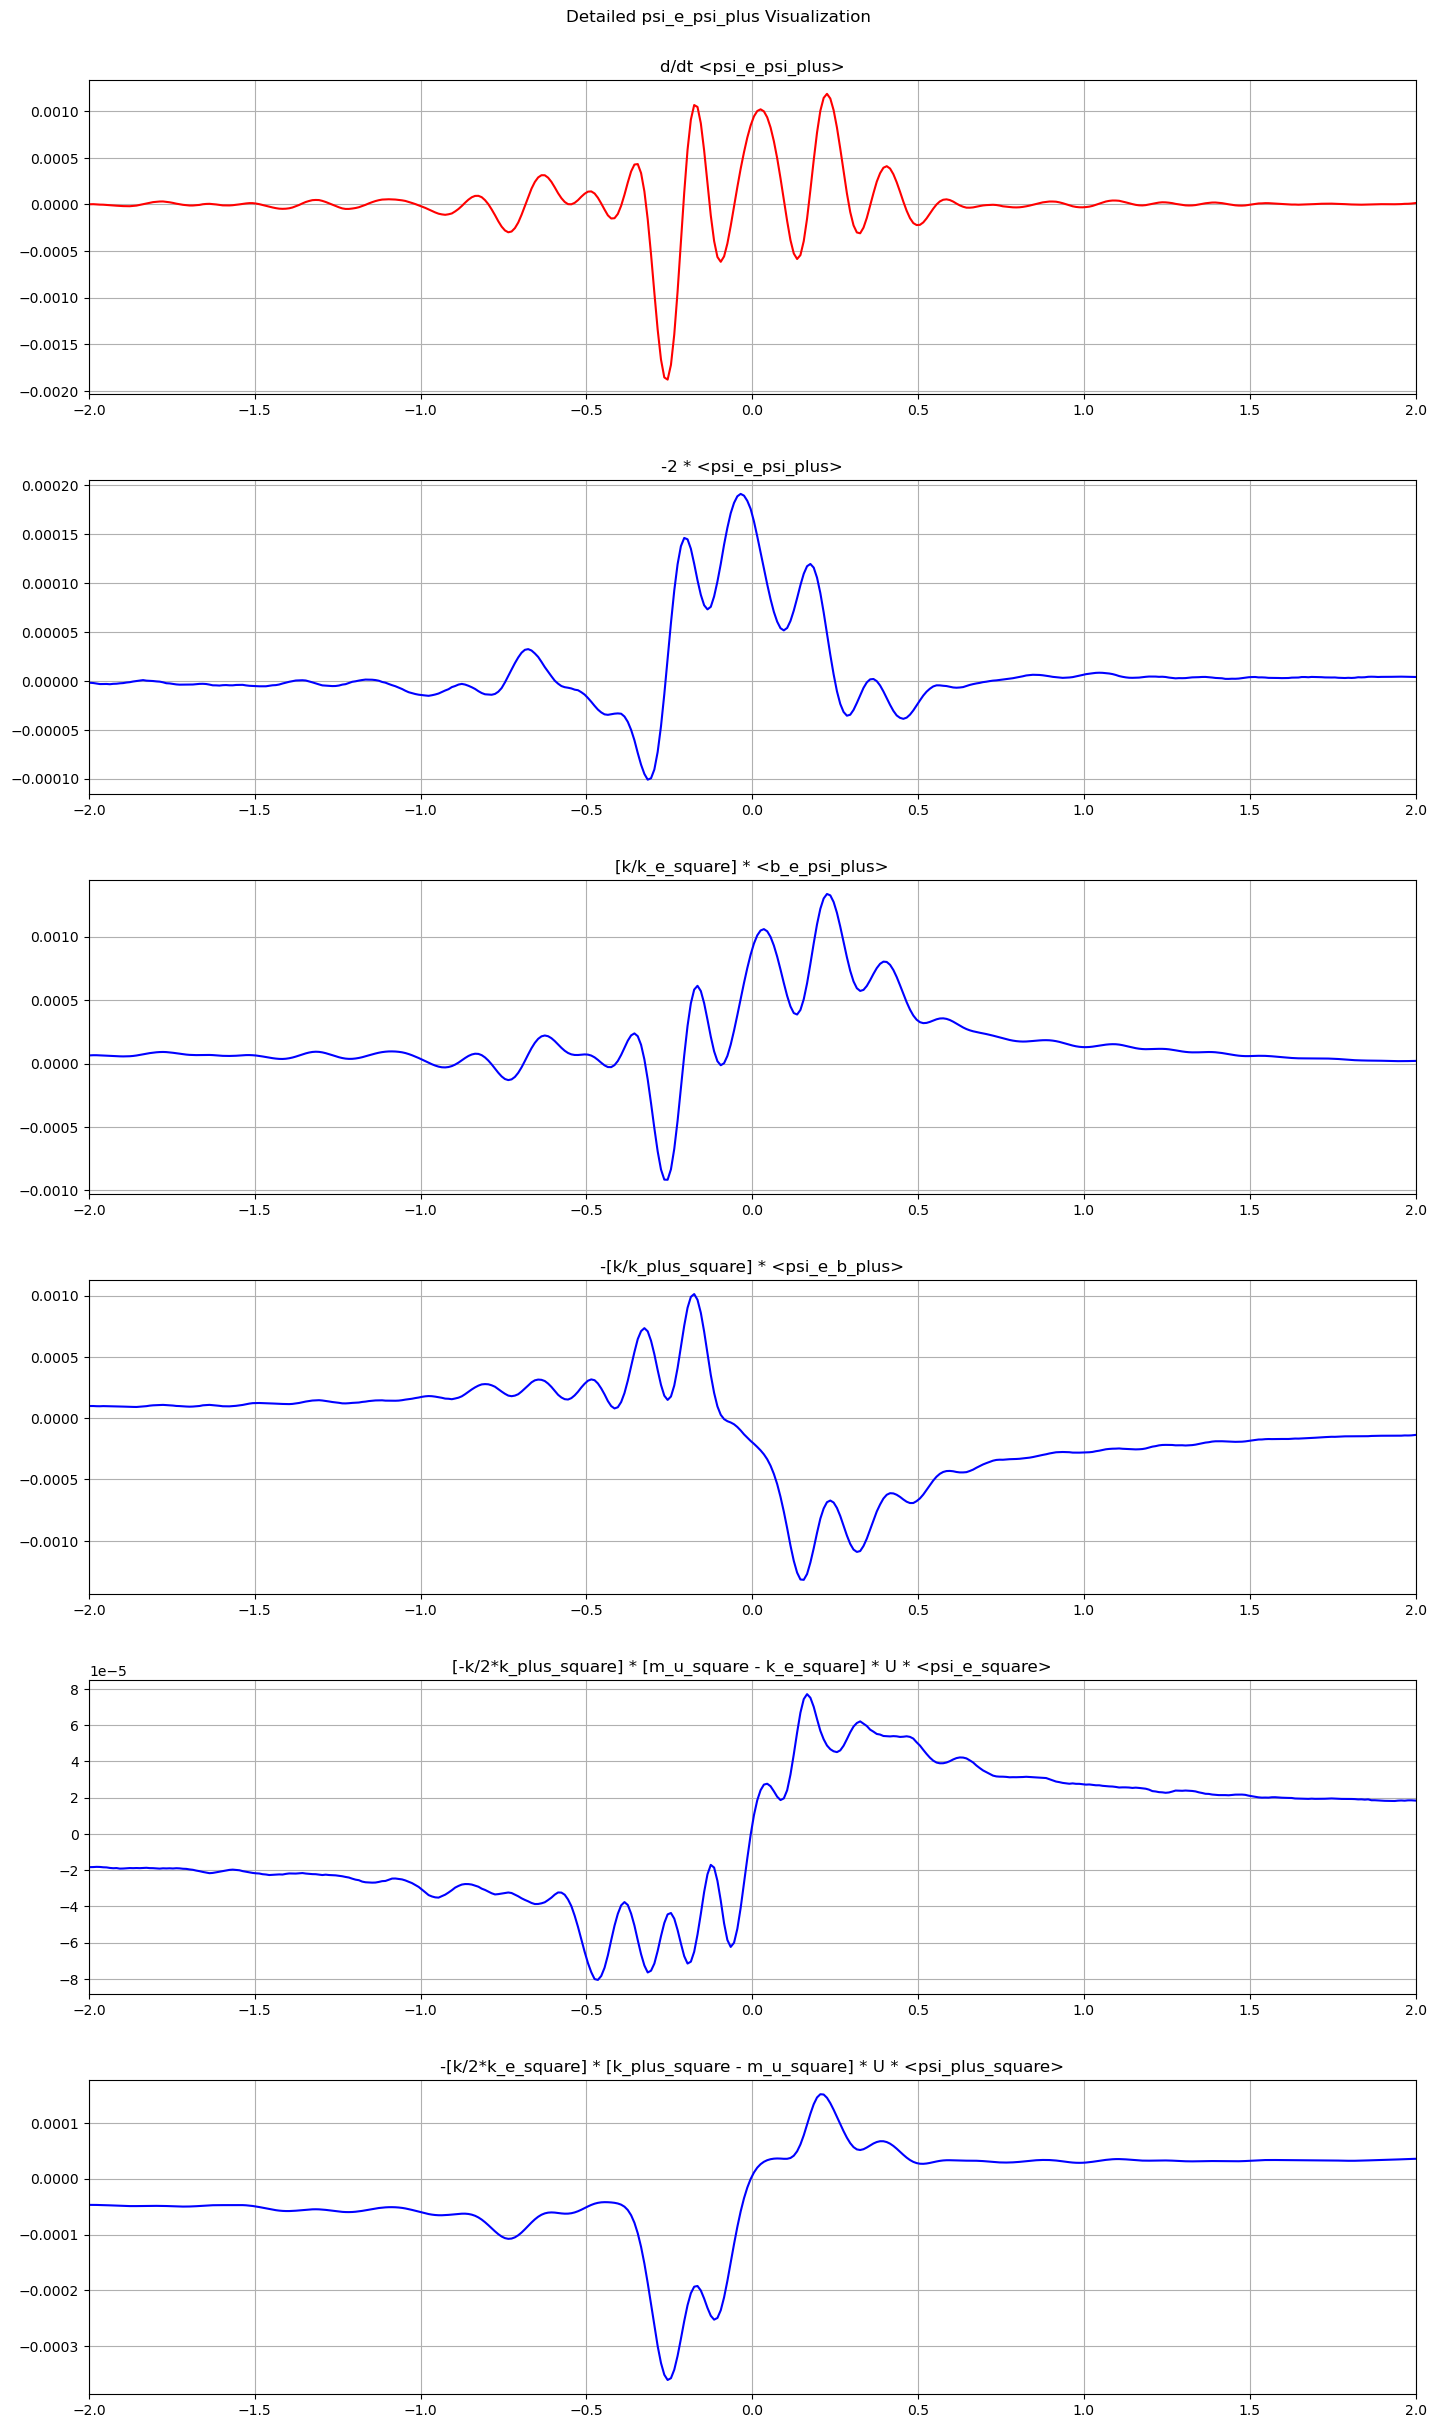

In [46]:
time_array = np.linspace(-5, 5, int(10/.01))
# time_array = np.arange(2000/10, 2000/10) * dt * 10
#fig, axs = plt.subplots(1,1, figsize = (8, 12))
x_limit = (-2, 2)

fig, axs = plt.subplots(6, 1, figsize=(15, 25))


axs[0].plot(time_array, s1[:, 0, 2],'r')
axs[0].set_title(f'd/dt <psi_e_psi_plus>')
axs[0].set_xlim(x_limit)
axs[0].grid()

axs[1].plot(time_array, -2 * average_R/(0.25 * k * (k_plus_square - k_e_square)),'b')
axs[1].set_title(f'-2 * <psi_e_psi_plus>')
axs[1].set_xlim(x_limit)
axs[1].grid()

axs[2].plot(time_array, (k/k_e_square) * average_b_e_psi_plus_list,'b')
axs[2].set_title(f'[k/k_e_square] * <b_e_psi_plus>')
axs[2].set_xlim(x_limit)
axs[2].grid()

axs[3].plot(time_array, (-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list,'b')
axs[3].set_title(f'-[k/k_plus_square] * <psi_e_b_plus>')
axs[3].set_xlim(x_limit)
axs[3].grid()

axs[4].plot(time_array, (-k/(2*k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e),'b')
axs[4].set_title(f'[-k/2*k_plus_square] * [m_u_square - k_e_square] * U * <psi_e_square>')
axs[4].set_xlim(x_limit) 
axs[4].grid()

axs[5].plot(time_array, (-k/(2*k_plus_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus),'b')
axs[5].set_title(f'-[k/2*k_e_square] * [k_plus_square - m_u_square] * U * <psi_plus_square>')
axs[5].set_xlim(x_limit)
axs[5].grid()


plt.suptitle(f"Detailed psi_e_psi_plus Visualization")



#plt.subplots_adjust(wspace=.4)
#plt.subplots_adjust(hspace=.4)
plt.tight_layout(pad = 3)
plt.show()

In [47]:
# time_array = np.linspace(-5, 5, int(10/.01))
# # time_array = np.arange(2000/10, 2000/10) * dt * 10
# #fig, axs = plt.subplots(1,1, figsize = (8, 12))
# x_limit = (-2, 2)

# fig, axs = plt.subplots(1, 1, figsize=(12, 8))

# sumOfIndividualItems = (-2 * average_R/(0.25 * k * (k_plus_square - k_e_square))) + ((k/k_e_square) * average_b_e_psi_plus_list) + ((-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list) + ((-k/(2*k_plus_square) * (np.square(m_u) - k_e_square) * average_UK_e_psi_e)) + ((-k/(2*k_e_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus))

# # sumOfIndividualItems = (-2 * average_R/(0.25 * k *fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# labels = [
#     'dC/dt[:, 0, 2]',
#     'sumOfIndividualItems',
#     '-2 * average_R/(0.25 * k * (k_plus_square - k_e_square))',
#     '(k/k_e_square) * average_b_e_psi_plus_list',
#     '(-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list',
#     '(-k/(2*k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e)',
#     '(-k/(2*k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus'
# ]

# sumOfIndividualItems = ((k / k_e_square) * average_b_e_psi_plus_list) + \
#                        ((-k / (2 * k_e_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus))
#                         # ((-k / (2 * k_e_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus))

# # ax.plot(time_array, dC_dt[:, 0, 2], '--r',label=labels[0], lw = 3)
# ax.plot(time_array, sumOfIndividualItems,'-k',label=labels[1], lw = 5)
# # ax.plot(time_array, -2 * average_R / (0.25 * k * (k_plus_square - k_e_square)), label=labels[2])
# # # ax.plot(time_array, average_R/1000, '-b', lw = 3)
# # ax.plot(time_array, (k / k_e_square) * average_b_e_psi_plus_list, label=labels[3])
# # ax.plot(time_array, (-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list, label=labels[4])
# # ax.plot(time_array, -(k / (2 * k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e), label=labels[5])
# # ax.plot(time_array, -(k / (2 * k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus), label=labels[6])


# ax.set_xlim(x_limit)

# ax.grid(True)
# ax.set_xlabel("Time")
# ax.set_ylabel("Values")

# ax.legend(loc='best')

# plt.suptitle(f"Detailed psi_e_psi_plus Visualization", fontsize=16)

# plt.tight_layout(pad=3)
# plt.show() 

# (k_plus_square - k_e_square))) + ((k/k_e_square) * average_b_e_psi_plus_list - ((k/k_e_square) * average_b_e_psi_plus_list[0])) + ((-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list - ((-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list[0])) + ((-k/(2*k_plus_square) * (np.square(m_u) - k_e_square) * average_UK_e_psi_e) - ((-k/(2*k_plus_square) * (np.square(m_u) - k_e_square) * average_UK_e_psi_e[0]))) - ((-k/(2*k_plus_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus) - ((-k/(2*k_plus_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus[0])))

# # axs.plot(time_array, dC_dt[:, 0, 2],'r')
# axs.plot(time_array, dC_dt[:, 0, 2], 'b')
# axs.plot(time_array, sumOfIndividualItems,'g')
# # axs.plot(time_array, s1[:, 0, 2])
# # axs.plot(time_array, -2 * average_R/(0.25 * k * (k_plus_square - k_e_square)))
# # axs.plot(time_array, (k/k_e_square) * average_b_e_psi_plus_list)
# # axs.plot(time_array, (-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list)
# # axs.plot(time_array, -(k/(2*k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e))
# # axs.plot(time_array, -(k/(2*k_plus_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus))
# axs.set_xlim(x_limit)
# axs.grid()


# plt.suptitle(f"Detailed psi_e_psi_plus Visualization (Same plot)")



# #plt.subplots_adjust(wspace=.4)
# #plt.subplots_adjust(hspace=.4)
# plt.tight_layout(pad = 3)
# plt.show()

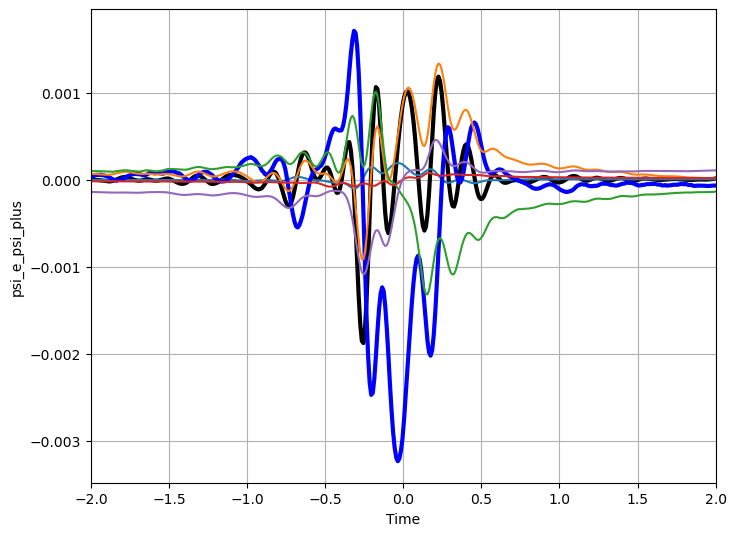

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

labels = [
    'dC/dt[:, 0, 2]',
    'psi_e_psi_plus',
    '-2 * average_R/(0.25 * k * (k_plus_square - k_e_square))',
    '(k/k_e_square) * average_b_e_psi_plus_list',
    '(-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list',
    '(-k/(2*k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e)',
    '(-k/(2*k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus'
]

sumOfIndividualItems = (-2 * average_R / (0.25 * k * (k_plus_square - k_e_square))) + \
                       ((k / k_e_square) * average_b_e_psi_plus_list) + \
                       ((-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list) + \
                       ((-k / (2 * k_plus_square) * (np.square(m_u) - k_e_square) * average_UK_e_psi_e)) + \
                       ((-k / (2 * k_e_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus))

# ax.plot(time_array, dC_dt[:, 0, 2], '--r',label=labels[0], lw = 3)
ax.plot(time_array, sumOfIndividualItems,'-k',label=labels[1], lw = 3)
ax.plot(time_array, -2 * average_R / (0.25 * k * (k_plus_square - k_e_square)), label=labels[2])
ax.plot(time_array, average_R/1000, '-b', lw = 3)
ax.plot(time_array, (k / k_e_square) * average_b_e_psi_plus_list, label=labels[3])
ax.plot(time_array, (-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list, label=labels[4])
ax.plot(time_array, -(k / (2 * k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e), label=labels[5])
ax.plot(time_array, -(k / (2 * k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus), label=labels[6])


ax.set_xlim(x_limit)
ax.grid(True)
ax.set_xlabel("Time")
ax.set_ylabel("psi_e_psi_plus")

# ax.legend(loc='best')

# plt.suptitle(f"Detailed psi_e_psi_plus Visualization", fontsize=16)

plt.tight_layout(pad=3)
plt.show()

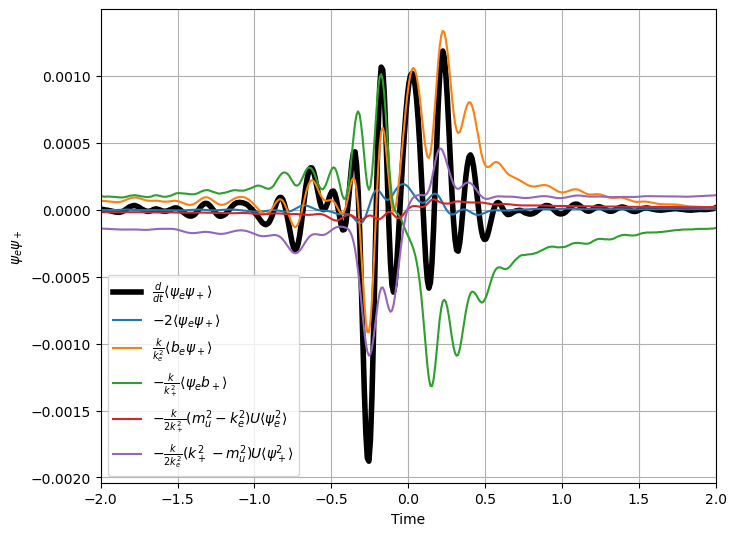

In [49]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Plot all terms with LaTeX-formatted labels
ax.plot(time_array, sumOfIndividualItems, '-k', lw=4, label=r"$\frac{d}{dt} \langle \psi_e \psi_+ \rangle$")
ax.plot(time_array, -2 * average_R / (0.25 * k * (k_plus_square - k_e_square)),
        label=r"$-2 \langle \psi_e \psi_+ \rangle$")
ax.plot(time_array, (k / k_e_square) * average_b_e_psi_plus_list,
        label=r"$\frac{k}{k_e^2} \langle b_e \psi_+ \rangle$")
ax.plot(time_array, (-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list,
        label=r"$-\frac{k}{k_+^2} \langle \psi_e b_+ \rangle$")
ax.plot(time_array, -(k / (2 * k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e),
        label=r"$-\frac{k}{2k_+^2} (m_u^2 - k_e^2) U \langle \psi_e^2 \rangle$")
ax.plot(time_array, -(k / (2 * k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus),
        label=r"$-\frac{k}{2k_e^2} (k_+^2 - m_u^2) U \langle \psi_+^2 \rangle$")

ax.set_xlim(x_limit)
ax.grid(True)
ax.set_xlabel("Time")
ax.set_ylabel(r"$\psi_e \psi_+$")

# Clean legend formatting
ax.legend(loc='best', fontsize=10)

plt.tight_layout(pad=3)
plt.show()


The green curve and the orange curve are responsible for the accleration of the jet near T = -0.4. These are also both heat fluxes. The terms driving the accleration is different from the ones causing the flip. 

### Pairwise Sum

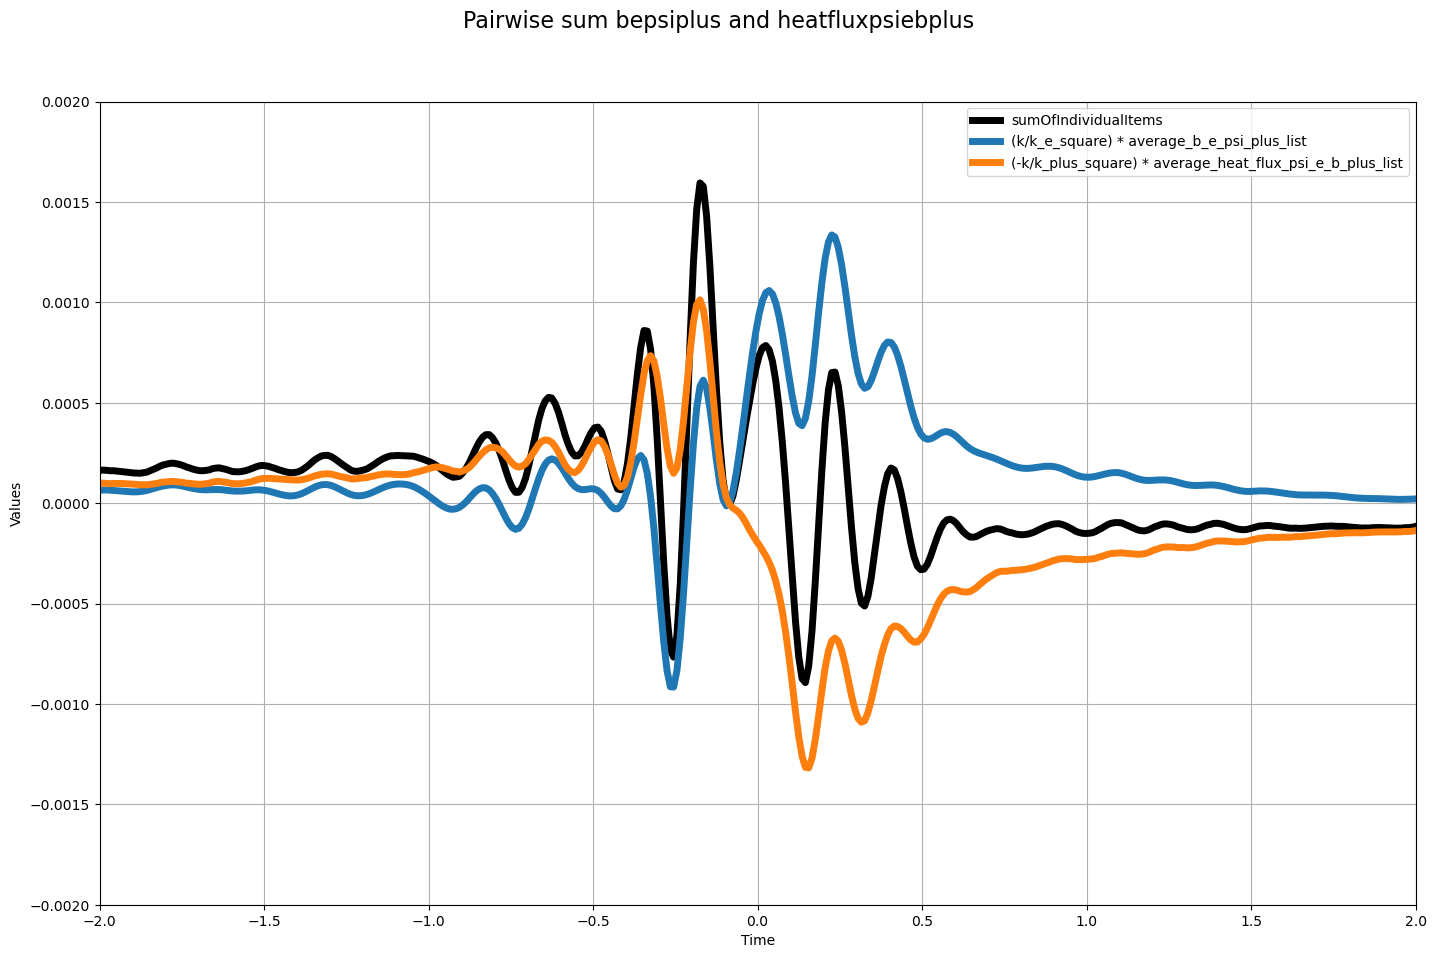

In [50]:
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

labels = [
    'dC/dt[:, 0, 2]',
    'sumOfIndividualItems',
    '-2 * average_R/(0.25 * k * (k_plus_square - k_e_square))',
    '(k/k_e_square) * average_b_e_psi_plus_list',
    '(-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list',
    '(-k/(2*k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e)',
    '(-k/(2*k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus'
]

sumOfIndividualItems = ((k / k_e_square) * average_b_e_psi_plus_list) + \
                       ((-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list) 
                        # ((-k / (2 * k_e_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus))

# ax.plot(time_array, dC_dt[:, 0, 2], '--r',label=labels[0], lw = 3)
ax.plot(time_array, sumOfIndividualItems,'-k',label=labels[1], lw = 5)
# ax.plot(time_array, -2 * average_R / (0.25 * k * (k_plus_square - k_e_square)), label=labels[2])
# # ax.plot(time_array, average_R/1000, '-b', lw = 3)
ax.plot(time_array, (k / k_e_square) * average_b_e_psi_plus_list, label=labels[3], lw = 5)
ax.plot(time_array, (-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list, label=labels[4], lw = 5)
# ax.plot(time_array, -(k / (2 * k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e), label=labels[5])
# ax.plot(time_array, -(k / (2 * k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus), label=labels[6])


ax.set_xlim(x_limit)
ax.set_ylim((-.002, .002))
ax.grid(True)
ax.set_xlabel("Time")
ax.set_ylabel("Values")

ax.legend(loc='best')

plt.suptitle(f"Pairwise sum bepsiplus and heatfluxpsiebplus", fontsize=16)

plt.tight_layout(pad=3)
plt.show()

#Sum of the 2 heat flux termslambda_values_filled = np.nan_to_num(lambda_values_truncat

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

labels = [
    'dC/dt[:, 0, 2]',
    'sumOfIndividualItems',labels[2],
    '-2 * average_R/(0.25 * k * (k_plus_square - k_e_square))',
    '(k/k_e_square) * average_b_e_psi_plus_list',
    '(-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list',
    '(-k/(2*k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e)',
    '(-k/(2*k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus'
]lambda_values_filled = np.nan_to_num(lambda_values_truncat * average_UK_e_psi_plus))

# ax.plot(time_array, dC_dt[:, 0, 2], '--r',label=labels[0], lw = 3)
ax.plot(time_array, sumOfIndividualItems,'-k',label=labels[1], lw = 5)
ax.plot(time_array, ((k / k_e_square) * average_b_e_psi_plus_list),label=labels[3], lw = 5)
ax.plot(time_array, (-k / (2 * k_e_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus),label=labels[6], lw = 5)
# ax.plot(time_array, -2 * average_R / (0.25 * k * (k_plus_square - k_e_square)), label=labels[2])
# # ax.plot(time_array, average_R/1000, '-b', lw = 3)
# ax.plot(time_array, (k / k_e_square) * average_b_e_psi_plus_list, label=labels[3])
# ax.plot(time_array, (-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list, label=labels[4])
# ax.plot(time_array, -(k / (2 * k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e), label=labels[5])
# ax.plot(time_array, -(k / (2 * k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus), label=labels[6])


ax.set_xlim(x_limit)
ax.set_ylim((-.002, .002))
ax.grid(True)
ax.set_xlabel("Time")
ax.set_ylabel("Values")
labels[2]
plt.show()

#Sum of the b_e_psi_plus + kinetic energy of exicted wave

SyntaxError: unmatched ')' (1711177651.py, line 11)

Reynold's Stress

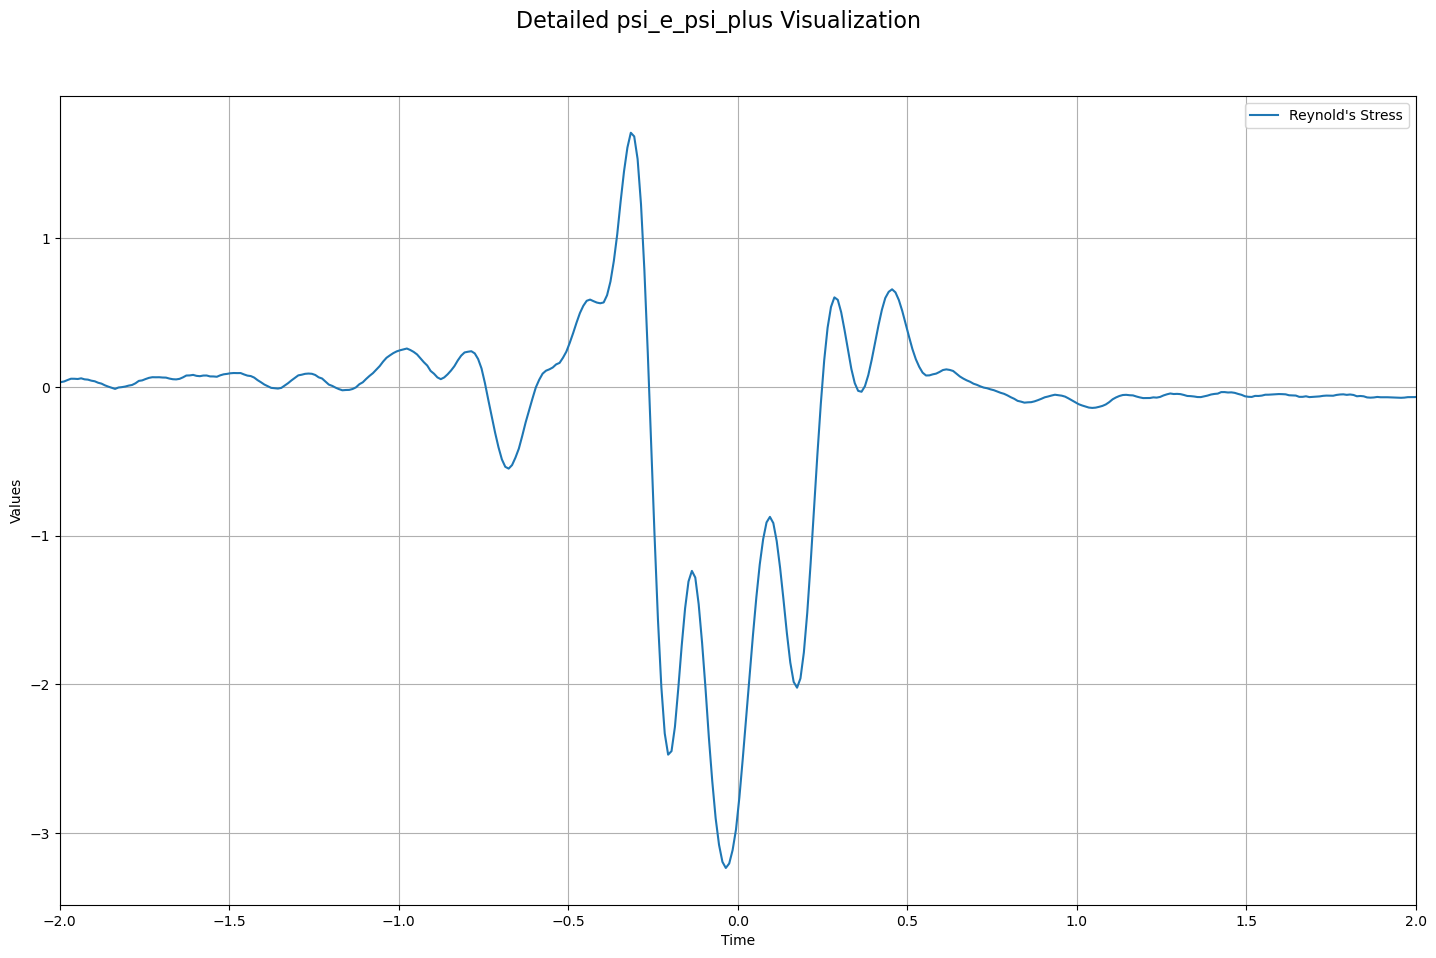

In [52]:
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

labels = [
    'dC/dt[:, 0, 2]',
    'sumOfIndividualItems',
    '-2 * average_R/(0.25 * k * (k_plus_square - k_e_square))',
    '(k/k_e_square) * average_b_e_psi_plus_list',
    '(-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list',
    '(-k/(2*k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e)',
    '(-k/(2*k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus'
]
labels[2]
sumOfIndividualItems = (-2 * average_R / (0.25 * k * (k_plus_square - k_e_square))) + \
                       ((k / k_e_square) * average_b_e_psi_plus_list) + \
                       ((-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list) + \
                       ((-k / (2 * k_plus_square) * (np.square(m_u) - k_e_square) * average_UK_e_psi_e)) + \
                       ((-k / (2 * k_e_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus))

# ax.plot(time_array, dC_dt[:, 0, 2], '--r',label=labels[0], lw = 3)
# ax.plot(time_array, sumOfIndividualItems,'-k',label=labels[1], lw = 5)
ax.plot(time_array, average_R , label="Reynold's Stress")
# ax.plot(time_array, average_R/1000, '-b', lw = 3)
# ax.plot(time_array, (k / k_e_square) * average_b_e_psi_plus_list, label=labels[3])
# ax.plot(time_array, (-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list, label=labels[4])
# ax.plot(time_array, -(k / (2 * k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e), label=labels[5])
# ax.plot(time_array, -(k / (2 * k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus), label=labels[6])


ax.set_xlim(x_limit)
ax.grid(True)
ax.set_xlabel("Time")
ax.set_ylabel("Values")

ax.legend(loc='best')

plt.suptitle(f"Detailed psi_e_psi_plus Visualization", fontsize=16)

plt.tight_layout(pad=3)
plt.show()

In [53]:
fig, ax = plt.subplots(1, 1, figsize=(15, 10))lambda_values_filled = np.nan_to_num(lambda_values_truncat

labels = [
    'dC/dt[:, 0, 2]',
    'sumOfIndividualItems',
    '-2 * average_R/(0.25 * k * (k_plus_square - k_e_square))',
    '(k/k_e_square) * average_b_e_psi_plus_list',
    '(-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list',
    '(-k/(2*k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e)',
    '(-k/(2*k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus'lambda_values_filled = np.nan_to_num(lambda_values_truncat
]

sumOfIndividualItems = -(k / (2 * k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus) + \
                       ((-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list)
                        # ((-k / (2 * k_e_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus))

# ax.plot(time_array, dC_dt[:, 0, 2], '--r',label=labels[0], lw = 3)
ax.plot(time_array, sumOfIndividualItems,'-k',label=labels[1], lw = 5)
# ax.plot(time_array, -2 * average_R / (0.25 * k * (k_plus_square - k_e_square)), label=labels[2])
# # ax.plot(time_array, average_R/1000, '-b', lw = 3)
# ax.plot(time_array, (k / k_e_square) * average_b_e_psi_plus_list, label=labels[3])
ax.plot(time_array, (-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list, label=labels[4], lw = 5)
# ax.plot(time_array, -(k / (2 * k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e), label=labels[5])
ax.plot(time_array, -(k / (2 * k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus), label=labels[6], lw = 5)


ax.set_xlim(x_limit)
ax.set_ylim((-.002, .002))
ax.grid(True)
ax.set_xlabel("Time")
ax.set_ylabel("Values")

ax.legend(loc='best')

plt.suptitle(f"Detailed psi_e_psi_plus Visualization", fontsize=16)

plt.tight_layout(pad=3)
plt.show()

#Sum of kepsi plus and psiebpluslambda_values_filled = np.nan_to_num(lambda_values_truncat

SyntaxError: closing parenthesis ']' does not match opening parenthesis '(' on line 10 (1411912571.py, line 11)

In [54]:
C02 = average_C_matrix[:, 0, 2]
time_array = np.linspace(-5, 5, 1000)

spline = CubicSpline(time_array, C02)
# spline_derivative = spline.derivative()
# dc02 = spline_derivative(time_array)

time_fine = np.linspace(-5, 5, 10000)
C02_fine = spline(time_fine)
C02_derivative_fine = spline.derivative()(time_fine)
C02_derivative_fine = C02_derivative_fine[9::10]

In [55]:
lambda_values_filled = np.nan_to_num(lambda_values_truncatx_limit = (-2, 2)

fig, axs = plt.subplots(1, 1, figsize=(12, 8))

sumOfIndividualItems = (-2 * average_R/(0.25 * k * (k_plus_square - k_e_square))) + ((k/k_e_square) * average_b_e_psi_plus_list) + ((-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list) + ((-k/(2*k_plus_square) * (np.square(m_u) - k_e_square) * average_UK_e_psi_e)) + ((-k/(2*k_e_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus))

# sumOfIndividualItems = (-2 * average_R/(0.25 * k * (k_plus_square - k_e_square))) + ((k/k_e_square) * average_b_e_psi_plus_list - ((k/k_e_square) * average_b_e_psi_plus_list[0])) + ((-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list - ((-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list[0])) + ((-k/(2*k_plus_square) * (np.square(m_u) - k_e_square) * average_UK_e_psi_e) - ((-k/(2*k_plus_square) * (np.square(m_u) - k_e_square) * average_UK_e_psi_e[0]))) - ((-k/(2*k_plus_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus) - ((-k/(2*k_plus_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus[0])))

# axs.plot(time_array, dC_dt[:, 0, 2],'r')
axs.plot(time_array, C02_derivative_fine, 'b')
axs.plot(time_array, sumOfIndividualItems,'g')
# axs.plot(time_array, s1[:, 0, 2])
# axs.plot(time_array, -2 * average_R/(0.25 * k * (k_plus_square - k_e_square)))
# axs.plot(time_array, (k/k_e_square) * average_b_e_psi_plus_list)
# axs.plot(time_array, (-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list)
# axs.plot(time_array, -(k/(2*k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e))
# axs.plot(time_array, -(k/(2*k_plus_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus))
axs.set_xlim(x_limit)
axs.grid()


plt.suptitle(f"Detailed psi_e_psi_plus Visualization (Same plot)")



#plt.subplots_adjust(wspace=.4)
#plt.subplots_adjust(hspace=.4)
plt.tight_layout(pad = 3)
plt.show()

SyntaxError: '(' was never closed (4100529952.py, line 1)

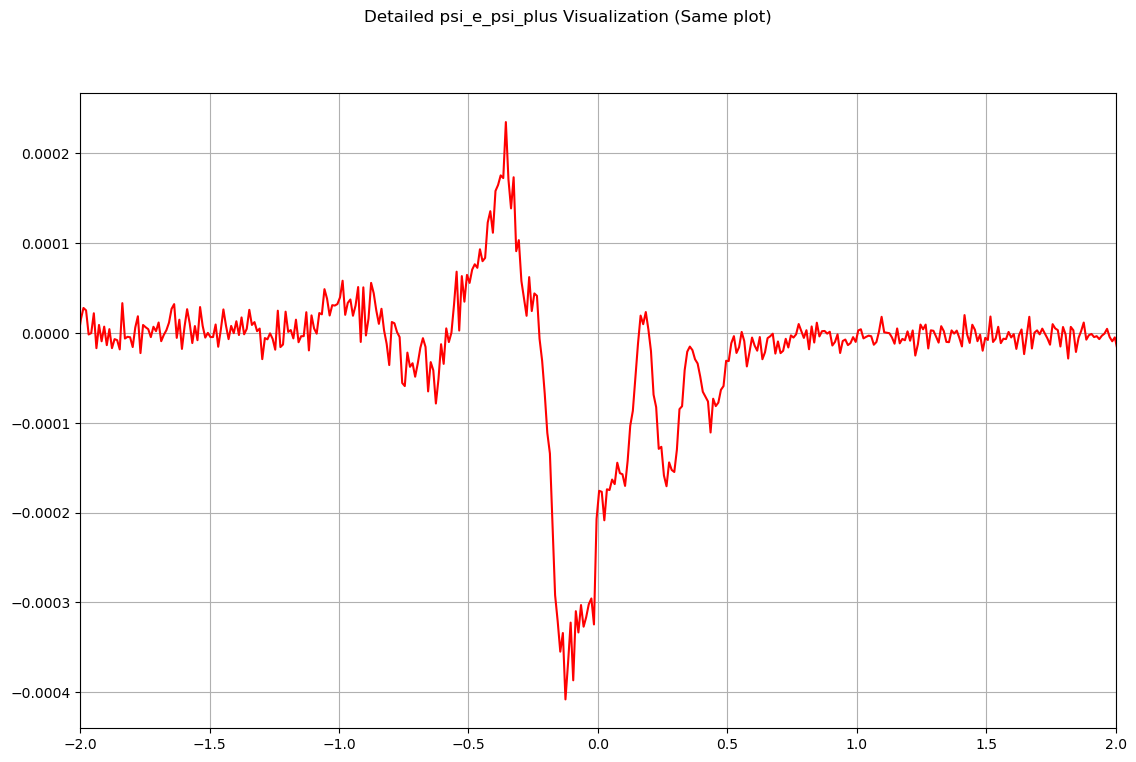

In [56]:
x_limit = (-2, 2)

fig, axs = plt.subplots(1, 1, figsize=(12, 8))

axs.plot(time_array,  C02_derivative_fine - sumOfIndividualItems, 'r')
axs.set_xlim(x_limit)
axs.grid()


plt.suptitle(f"Detailed psi_e_psi_plus Visualization (Same plot)")
plt.tight_layout(pad = 3)
plt.show()


In [57]:
s1 = average_WC + average_WC_Transpose + average_ULC + average_UCLT + epsilon*bigQ
# s1 *= 100

In [58]:
average_C_matrix = np.array(average_C_Matrix)

delta_t = .001  

dC_dt = np.zeros_like(average_C_matrix)

dC_dt[0] = (average_C_matrix[1] - average_C_matrix[0]) / delta_tlambda_values_filled = np.nan_to_num(lambda_values_truncat

for i in range(1, len(average_C_matrix) - 1):
    dC_dt[i] = (average_C_matrix[i + 1] - average_C_matrix[i - 1]) / (2 * delta_t)

dC_dt[-1] = (average_C_matrix[-1] - average_C_matrix[-2]) / delta_t
dC_dt = dC_dt/10

SyntaxError: cannot assign to expression (2816279055.py, line 7)

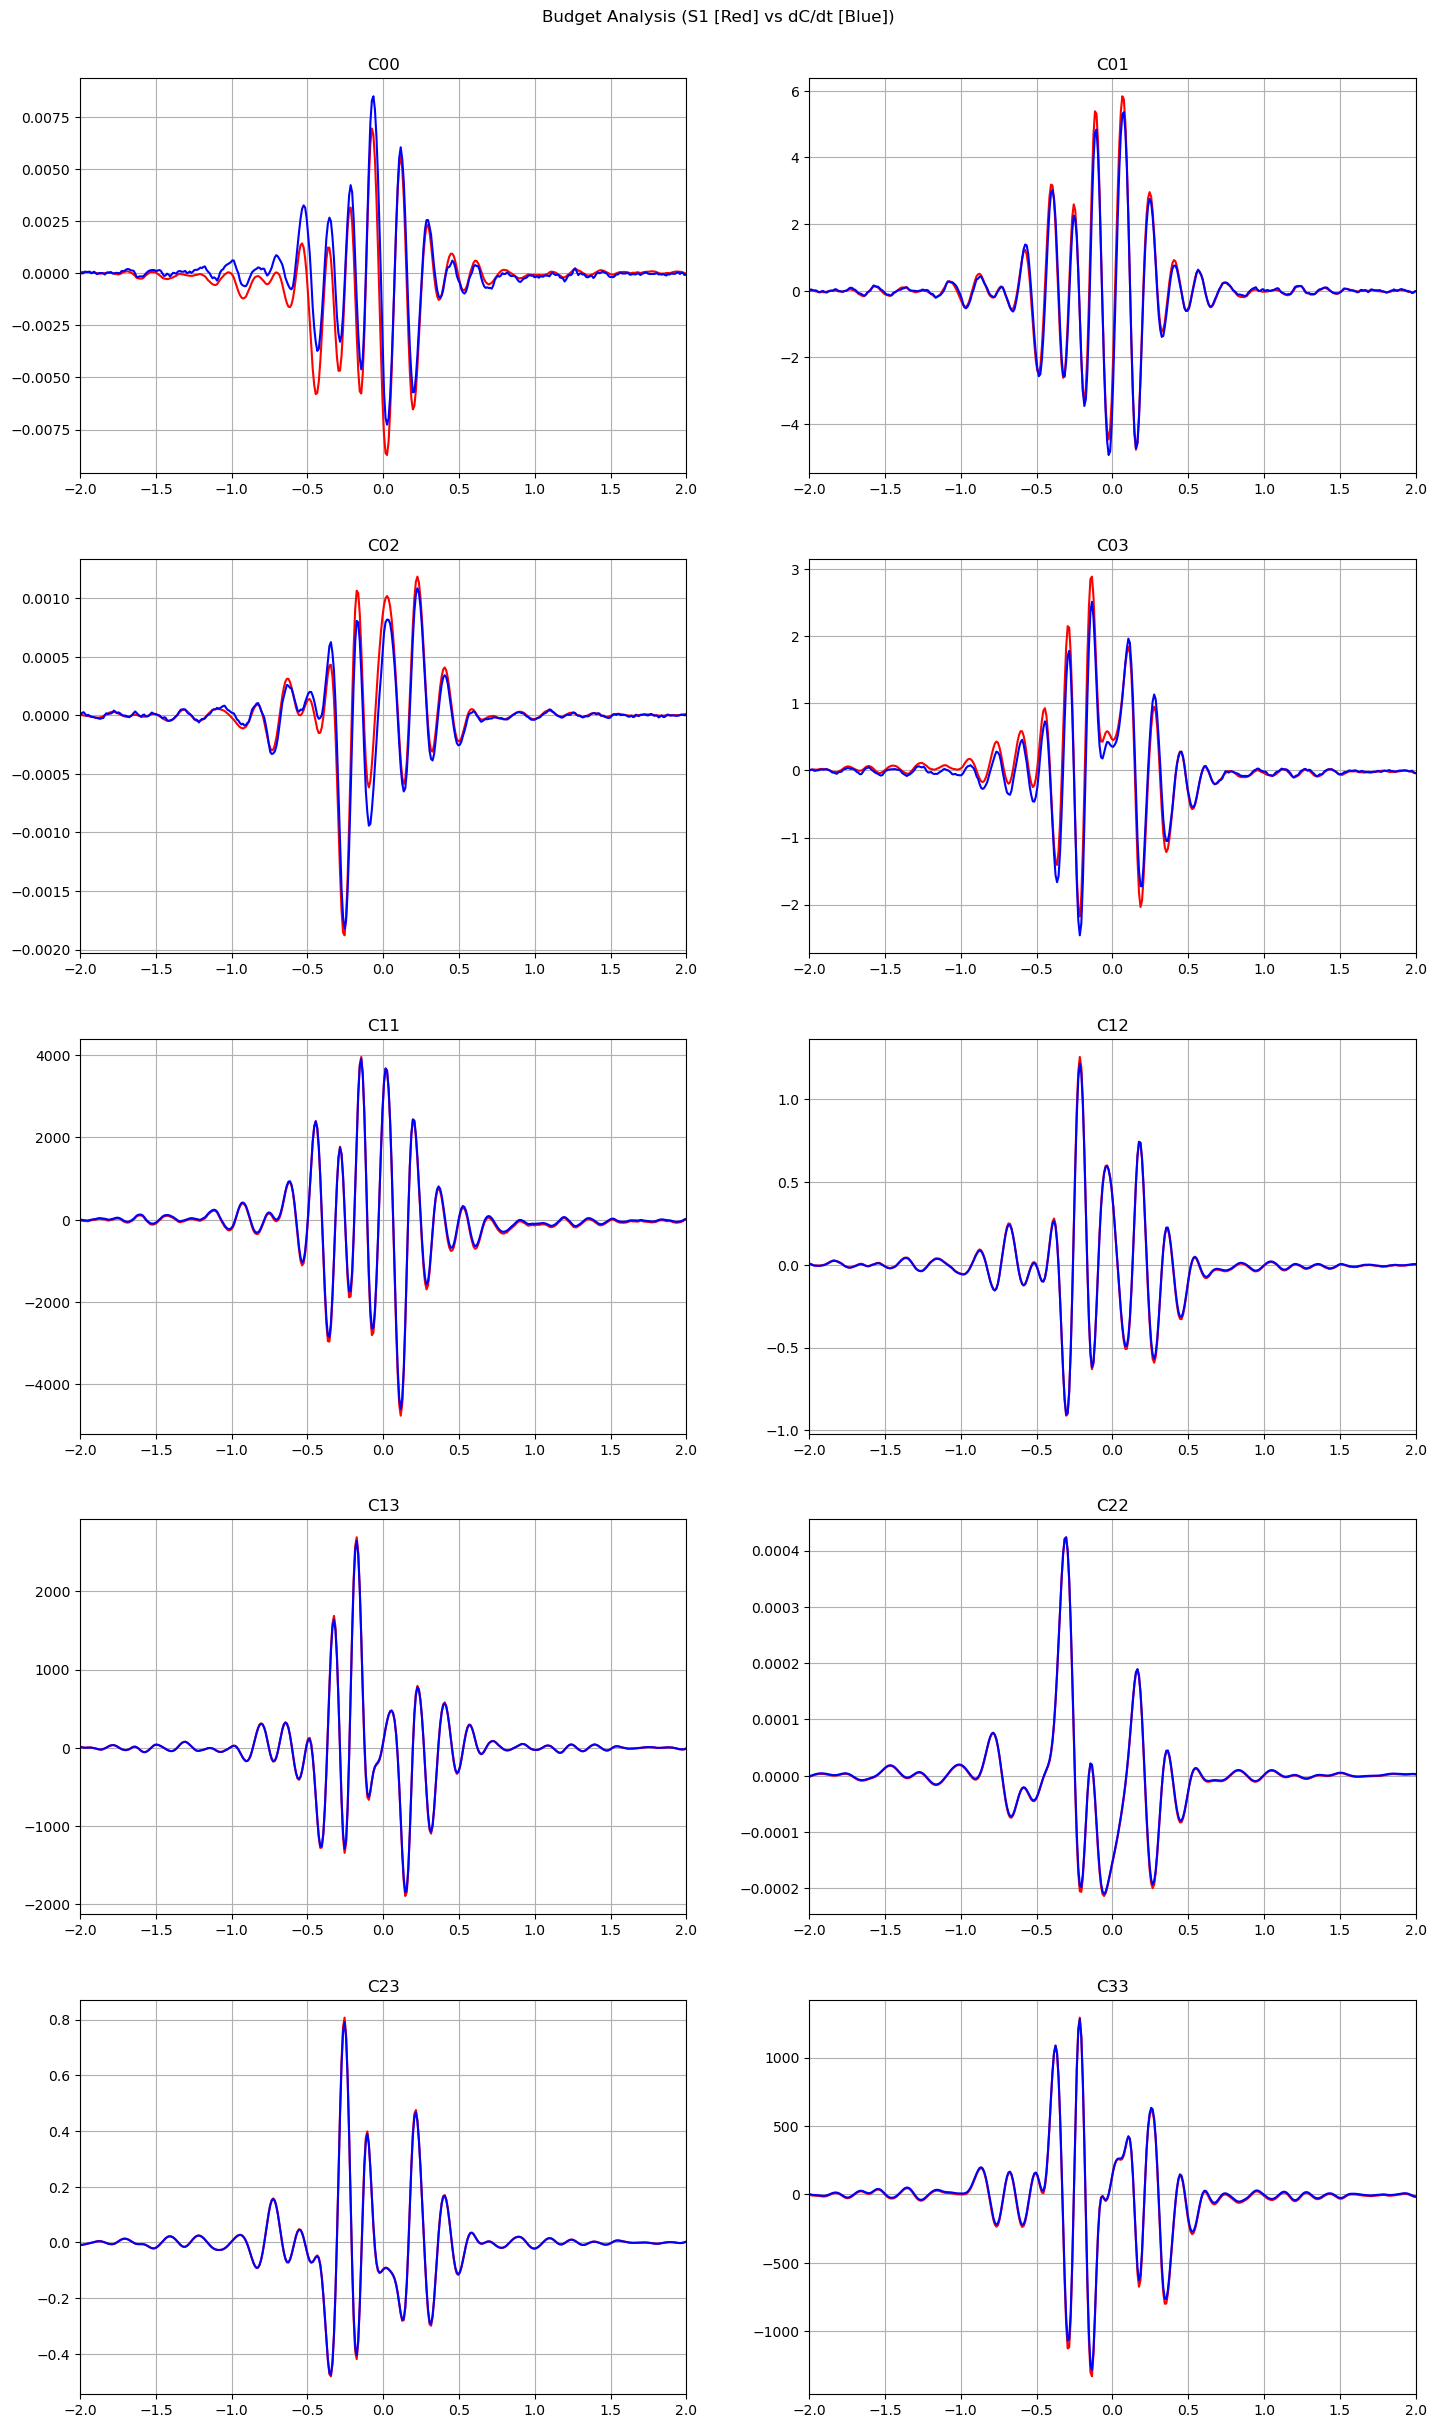

In [59]:
time_array = np.linspace(-5, 5, 1000)
# time_array = np.arange(2000/10, 2000/10) * dt * 10
#fig, axs = plt.subplots(1,1, figsize = (8, 12))
x_limit = (-2, 2)

fig, axs = plt.subplots(5, 2, figsize=(15, 25))


axs[0, 0].plot(time_array, s1[:, 0, 0],'r')
axs[0, 0].plot(time_array, dC_dt[:, 0, 0],'b')
axs[0, 0].set_title(f'C00')
axs[0, 0].set_xlim(x_limit)
axs[0, 0].grid()

axs[0, 1].plot(time_array, s1[:, 0, 1],'r')
axs[0, 1].plot(time_array, dC_dt[:, 0, 1],'b')
axs[0, 1].set_title(f'C01')
axs[0, 1].set_xlim(x_limit)
axs[0, 1].grid()

axs[1, 0].plot(time_array, s1[:, 0, 2],'r')
axs[1, 0].plot(time_array, dC_dt[:, 0, 2],'b')
axs[1, 0].set_title(f'C02')
axs[1, 0].set_xlim(x_limit)
axs[1, 0].grid()

axs[1, 1].plot(time_array, s1[:, 0, 3],'r')
axs[1, 1].plot(time_array, dC_dt[:, 0, 3],'b')
axs[1, 1].set_title(f'C03')
axs[1, 1].set_xlim(x_limit)
axs[1, 1].grid()

axs[2, 0].plot(time_array, s1[:, 1, 1],'r')
axs[2, 0].plot(time_array, dC_dt[:, 1, 1],'b')
axs[2, 0].set_title(f'C11')
axs[2, 0].set_xlim(x_limit)
axs[2, 0].grid()

axs[2, 1].plot(time_array, s1[:, 1, 2],'r')
axs[2, 1].plot(time_array, dC_dt[:, 1, 2],'b')
axs[2, 1].set_title(f'C12')
axs[2, 1].set_xlim(x_limit)
axs[2, 1].grid()

axs[3, 0].plot(time_array, s1[:, 1, 3],'r')
axs[3, 0].plot(time_array, dC_dt[:, 1, 3],'b')
axs[3, 0].set_title(f'C13')
axs[3, 0].set_xlim(x_limit)
axs[3, 0].grid()

axs[3, 1].plot(time_array, s1[:, 2, 2],'r')
axs[3, 1].plot(time_array, dC_dt[:, 2, 2],'b')
axs[3, 1].set_title(f'C22')
axs[3, 1].set_xlim(x_limit)
axs[3, 1].grid()

axs[4, 0].plot(time_array, s1[:, 2, 3],'r')
axs[4, 0].plot(time_array, dC_dt[:, 2, 3],'b')
axs[4, 0].set_title(f'C23')
axs[4, 0].set_xlim(x_limit)
axs[4, 0].grid()

axs[4, 1].plot(time_array, s1[:, 3, 3],'r')
axs[4, 1].plot(time_array, dC_dt[:, 3, 3],'b')
axs[4, 1].set_title(f'C33')
axs[4, 1].set_xlim(x_limit)
axs[4, 1].grid()


plt.suptitle(f"Budget Analysis (S1 [Red] vs dC/dt [Blue])")



#plt.subplots_adjust(wspace=.4)
#plt.subplots_adjust(hspace=.4)
plt.tight_layout(pad = 3)
plt.show()

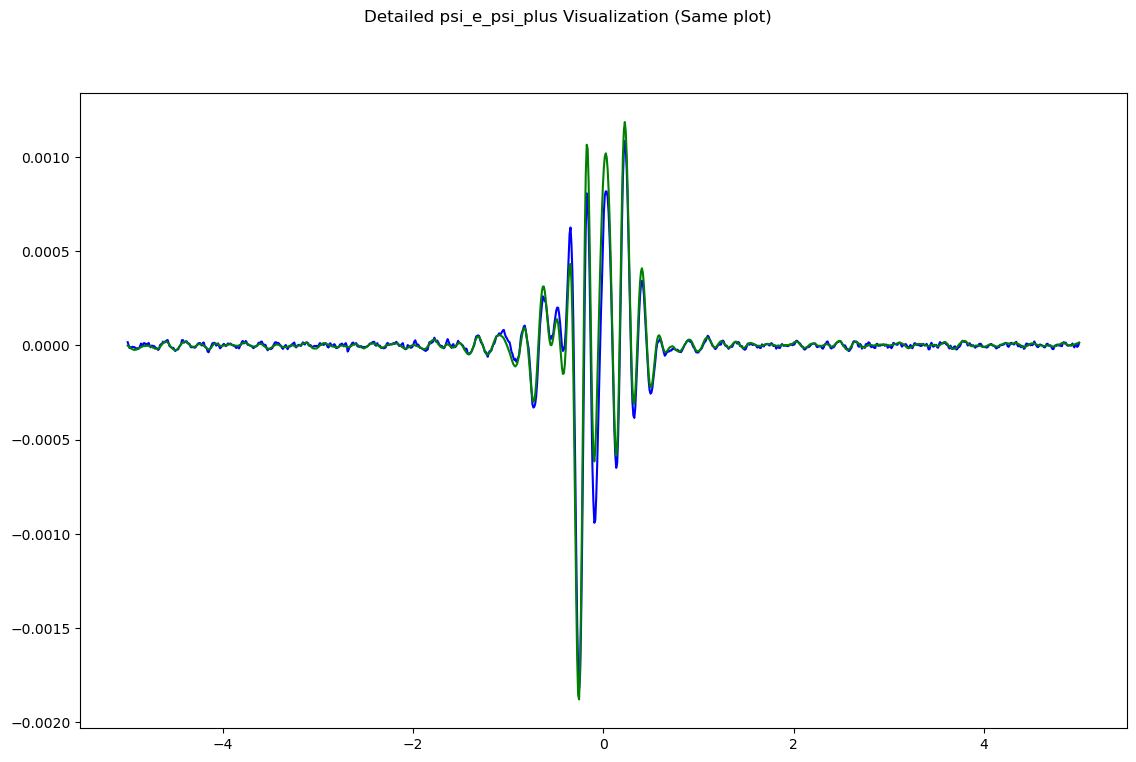

In [60]:
x_limit = (-2, 2)

fig, axs = plt.subplots(1, 1, figsize=(12, 8))

sumOfIndividualItems = (-2 * average_R/(0.25 * k * (k_plus_square - k_e_square))) + ((k/k_e_square) * average_b_e_psi_plus_list) + ((-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list) + ((-k/(2*k_plus_square) * (np.square(m_u) - k_e_square) * average_UK_e_psi_e)) + ((-k/(2*k_e_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus))

# sumOfIndividualItems = (-2 * average_R/(0.25 * k * (k_plus_square - k_e_square))) + ((k/k_e_square) * average_b_e_psi_plus_list - ((k/k_e_square) * average_b_e_psi_plus_list[0])) + ((-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list - ((-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list[0])) + ((-k/(2*k_plus_square) * (np.square(m_u) - k_e_square) * average_UK_e_psi_e) - ((-k/(2*k_plus_square) * (np.square(m_u) - k_e_square) * average_UK_e_psi_e[0]))) - ((-k/(2*k_plus_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus) - ((-k/(2*k_plus_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus[0])))

# axs.plot(time_array, dC_dt[:, 0, 2],'r')
axs.plot(time_array, dC_dt[:, 0, 2], 'b')
axs.plot(time_array, sumOfIndividualItems,'g')
# axs.plot(time_array, s1[:, 0, 2])lambda_values_filled = np.nan_to_num(lambda_values_truncat

plt.suptitle(f"Detailed psi_e_psi_plus Visualization (Same plot)")



#plt.subplots_adjust(wspace=.4)
#plt.subplots_adjust(hspace=.4)
plt.tight_layout(pad = 3)
plt.show()

In [61]:
C00 = average_C_matrix[:, 0, 0]
time_array = np.linspace(-5, 5, 1000)

spline = CubicSpline(time_array, C00)
# spline_derivative = spline.derivative()
# dc02 = spline_derivative(time_array)

time_fine = np.linspace(-5, 5, 10000)
C00_fine = spline(time_fine)
C00_derivative_fine = spline.derivative()(time_fine)
C00_derivative_fine = C00_derivative_fine[9::10]

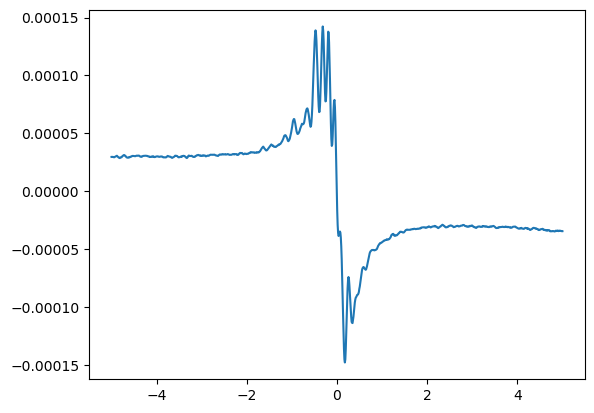

In [62]:
plt.plot(time_array, average_U * average_k_e_psi_e_list)

In [63]:
U_k_e_psi_e = np.array([
    np.array(u) * np.array(k)
    for u, k in zip(df['u_list'], df['k_e_psi_e_list'])
])


In [64]:
U_k_e_psi_e_average = average_arrays(*list(U_k_e_psi_e))

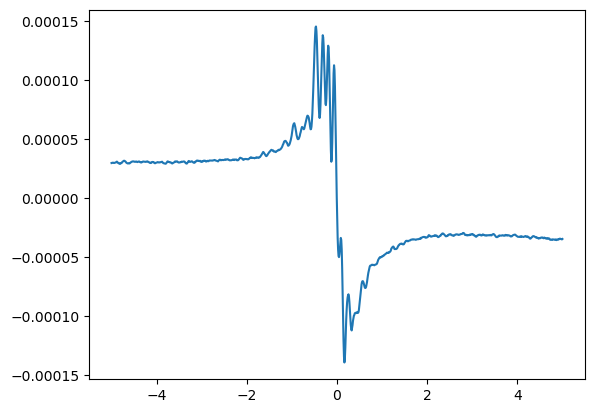

In [65]:
plt.plot(time_array, U_k_e_psi_e_average)

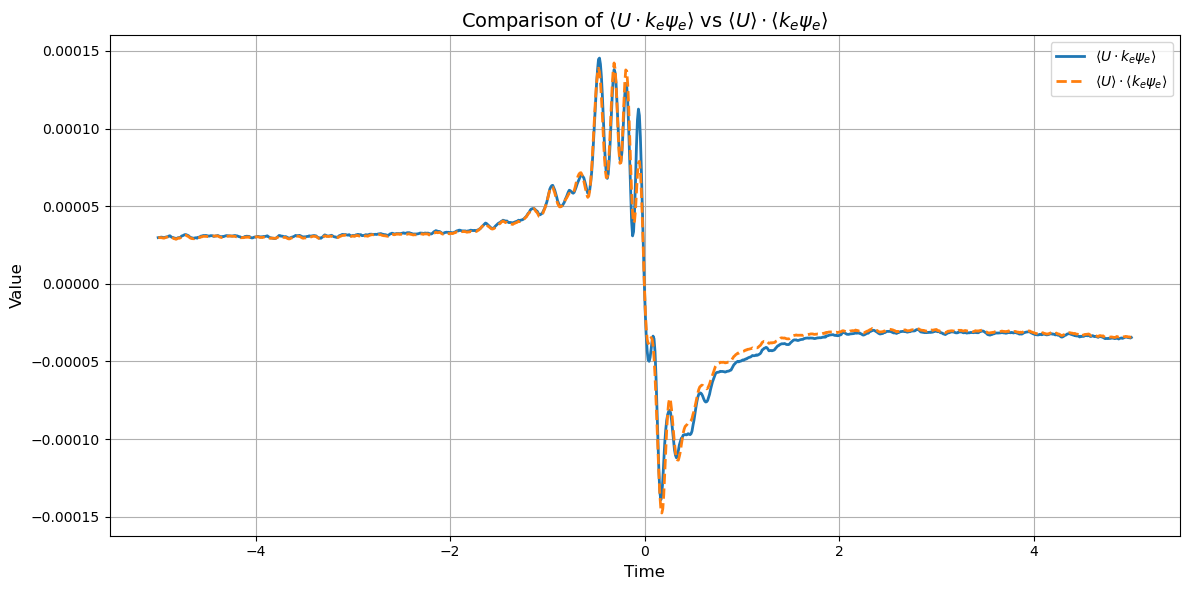

In [66]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(time_array, U_k_e_psi_e_average, label=r'$\langle U \cdot k_{e}\psi_{e} \rangle$', linewidth=2)
ax.plot(time_array, average_U * average_k_e_psi_e_list, 
        label=r'$\langle U \rangle \cdot \langle k_{e}\psi_{e} \rangle$', linestyle='--', linewidth=2)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title(r'Comparison of $\langle U \cdot k_{e}\psi_{e} \rangle$ vs $\langle U \rangle \cdot \langle k_{e}\psi_{e} \rangle$', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True)

plt.tight_layout()
plt.show()


In [67]:
standard_error_diff= np.std(U_k_e_psi_e_average-(average_U * average_k_e_psi_e_list), axis=0) / np.sqrt(1000)

In [68]:
standard_error_diff

1.2423179836096926e-07

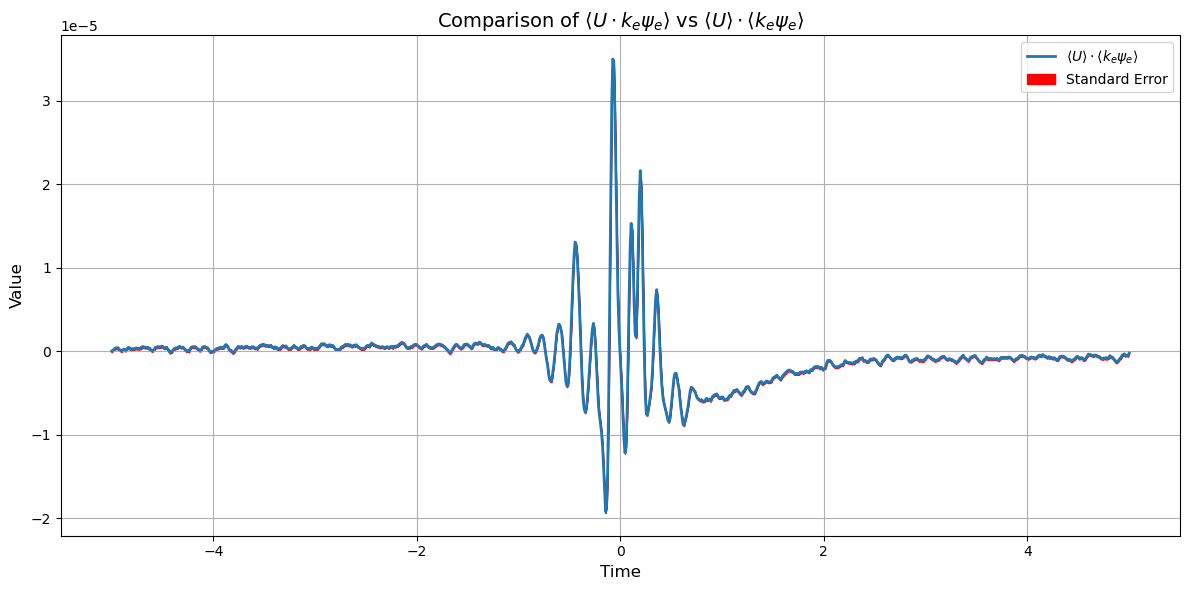

In [69]:
fig, ax = plt.subplots(figsize=(12, 6))
calc_array = U_k_e_psi_e_average-(average_U * average_k_e_psi_e_list)
# ax.plot(time_array, U_k_e_psi_e_average, label=r'$\langle U \cdot k_{e}\psi_{e} \rangle$', linewidth=2)
ax.plot(time_array, calc_array,
        label=r'$\langle U \rangle \cdot \langle k_{e}\psi_{e} \rangle$', linestyle='-', linewidth=2)

ax.fill_between(time_array, 
                calc_array - standard_error_diff, 
                calc_array + standard_error_diff, 
                alpha=1, label='Standard Error',color='red')

# ax.errorbar(time_array, 
#             U_k_e_psi_e_average - (average_U * average_k_e_psi_e_list), 
#             yerr=standard_error_diff, 
#             label=r'$\langle U \rangle \cdot \langle k_{e}\psi_{e} \rangle$', 
#             linestyle='--', 
#             linewidth=2, 
#             capsize=3)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title(r'Comparison of $\langle U \cdot k_{e}\psi_{e} \rangle$ vs $\langle U \rangle \cdot \langle k_{e}\psi_{e} \rangle$', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True)

plt.tight_layout()
plt.show()



In [70]:
def std_across_axis(arrays):
    return np.std(arrays, axis=0)

In [71]:
U_k_e_psi_e_stdev = std_across_axis(U_k_e_psi_e)

In [72]:
U_k_e_psi_e_stdev.shape

(1000,)

In [73]:
U_k_e_psi_e_stError = U_k_e_psi_e_stdev/100

In [74]:
U_k_e_psi_e.shape

(5000, 1000)

In [75]:
U_k_e_psi_e_average = average_arrays(*list(U_k_e_psi_e))

In [76]:
U_k_e_psi_e_average.shape

(1000,)

In [77]:
average_U_Ke_psi_e = average_U * average_k_e_psi_e_list
average_U_Ke_psi_e.shape

(1000,)

In [78]:
std_U = np.std(df['u_list'].tolist(), axis=0)
std_K_e_psi_e = np.std(df['k_e_psi_e_list'].tolist(), axis=0)
std_U.shape, std_K_e_psi_e.shape

((1000,), (1000,))

In [79]:
std_err_U = std_U / 100
std_err_k_e_psi_e = std_K_e_psi_e / 100

In [80]:
st_err_U_K_e_psi_e = average_U * average_k_e_psi_e_list * np.sqrt((std_err_U / average_U) ** 2 + (std_err_k_e_psi_e / average_k_e_psi_e_list) ** 2)
st_err_U_K_e_psi_e.shape

(1000,)

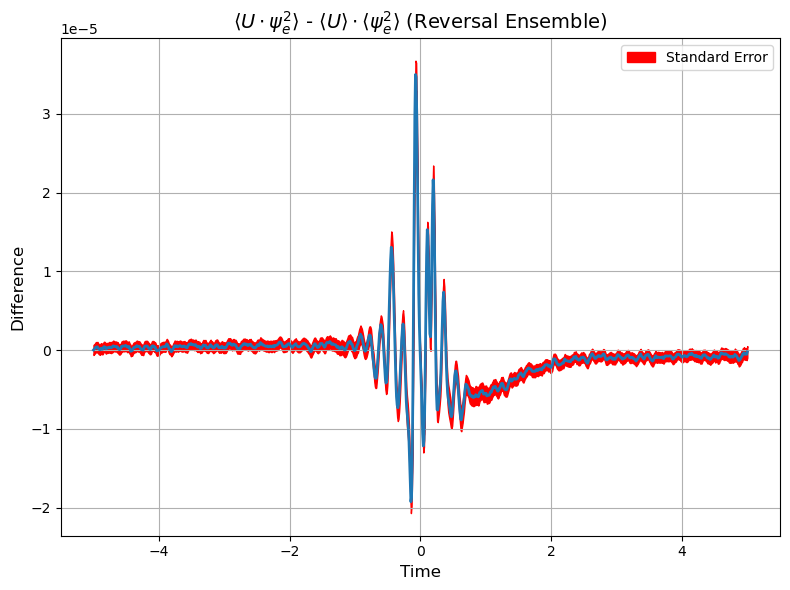

In [81]:
fig, ax = plt.subplots(figsize=(8, 6))
standard_error_diff = np.sqrt(st_err_U_K_e_psi_e ** 2 + U_k_e_psi_e_stError ** 2)
calc_array = U_k_e_psi_e_average - average_U_Ke_psi_e
# ax.plot(time_array, U_k_e_psi_e_average, label=r'$\langle U \cdot k_{e}\psi_{e} \rangle$', linewidth=2)
ax.plot(time_array, calc_array,linestyle='-', linewidth=2)

ax.fill_between(time_array, 
                calc_array - standard_error_diff, 
                calc_array + standard_error_diff, 
                alpha=1, label='Standard Error',color='red')

# ax.errorbar(time_array, 
#             U_k_e_psi_e_average - (a
#             capsize=3)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Difference', fontsize=12)
ax.set_title(r'$\langle U \cdot \psi_{e}^2 \rangle$ - $\langle U \rangle \cdot \langle \psi_{e}^2 \rangle$ (Reversal Ensemble)', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True)

plt.tight_layout()
plt.show()


/tmp/ipykernel_1217685/3179727732.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


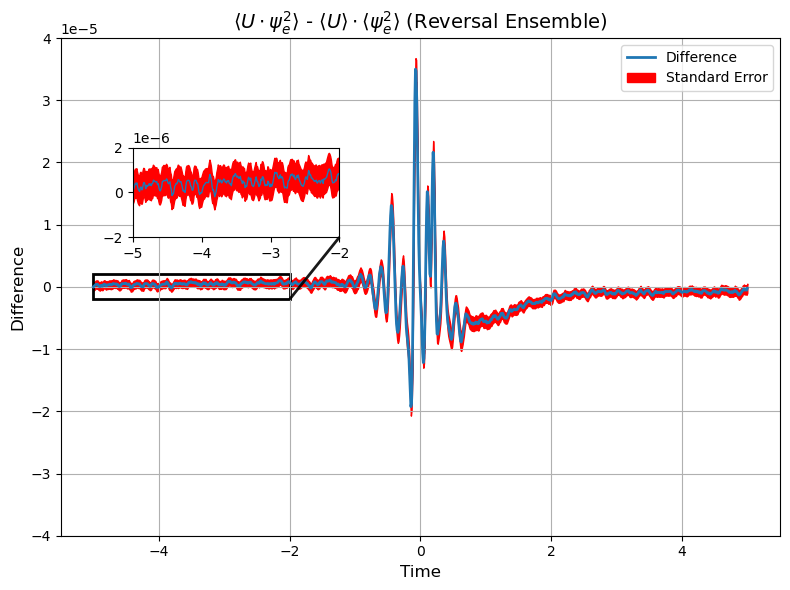

In [82]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# assuming these exist:
# time_array
# st_err_U_K_e_psi_e
# U_k_e_psi_e_stError
# U_k_e_psi_e_average
# average_U_Ke_psi_e

fig, ax = plt.subplots(figsize=(8, 6))

standard_error_diff = np.sqrt(st_err_U_K_e_psi_e ** 2 + U_k_e_psi_e_stError ** 2)
calc_array = U_k_e_psi_e_average - average_U_Ke_psi_e

# ===================== MAIN PLOT =====================
ax.plot(time_array, calc_array, linestyle='-', linewidth=2, label='Difference')

ax.fill_between(
    time_array,
    calc_array - standard_error_diff,
    calc_array + standard_error_diff,
    alpha=1,
    label='Standard Error',
    color='red'
)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Difference', fontsize=12)
ax.set_title(
    r'$\langle U \cdot \psi_{e}^2 \rangle$ - $\langle U \rangle \cdot \langle \psi_{e}^2 \rangle$ (Reversal Ensemble)',
    fontsize=14
)
ax.legend(fontsize=10)
ax.set_ylim(-4e-5, 4e-5)
ax.grid(True)

# ===================== INSET SETUP =====================
# center & window in time you want to zoom around
t_center = -3.5
t_half = 1.5           # window: [t_center - t_half, t_center + t_half]
t1, t2 = t_center - t_half, t_center + t_half

mask = (time_array >= t1) & (time_array <= t2)

# vertical limits based on data ± error in that window
local_lower = (calc_array - standard_error_diff)[mask]
local_upper = (calc_array + standard_error_diff)[mask]
y_min = np.min(local_lower)
y_max = np.max(local_upper)
pad = 0.1 * (y_max - y_min) if y_max > y_min else 1e-6
# pad = 0.1 * (y_max - y_min) 

# ===================== INSET AXES (BOTTOM-RIGHT, SQUARE) =====================
# We use bbox_to_anchor in *axes* coordinates to control position:
# (x0, y0, width, height), all in [0, 1] relative to the main axes.
ax_ins = inset_axes(
    ax,
    width="115%",                # size relative to bbox_to_anchor
    height="60%",
    loc="lower left",           # corner of the inset that attaches to bbox
    bbox_to_anchor=(0.10, .6, 0.25, 0.30),  # bottom-right-ish, square-ish
    bbox_transform=ax.transAxes,
    borderpad=0
)

# same line + shading inside inset
ax_ins.plot(time_array, calc_array, linestyle='-', linewidth=1.0)
ax_ins.fill_between(
    time_array,
    calc_array - standard_error_diff,
    calc_array + standard_error_diff,
    alpha=1,
    color='red'
)

ax_ins.set_xlim(t1, t2)
ax_ins.set_ylim(-2e-6, 2e-6)

# clean inset ticks (comment out if you want them)
# ax_ins.set_xticks([])
# ax_ins.set_yticks([])

# rectangle + one connector between main and inset
pp, p1, p2 = mark_inset(ax, ax_ins, loc1=4, loc2=1, fc="none", ec="0.5")
pp.set_edgecolor("black")
pp.set_linewidth(2.0)


p2.set_visible(False)
p1.set_linewidth(2.0)
p1.set_color("black")
p1.set_alpha(0.9)

plt.tight_layout()
plt.show()


3Corr For psi e psi plus Interesting, so this does include the 3corr

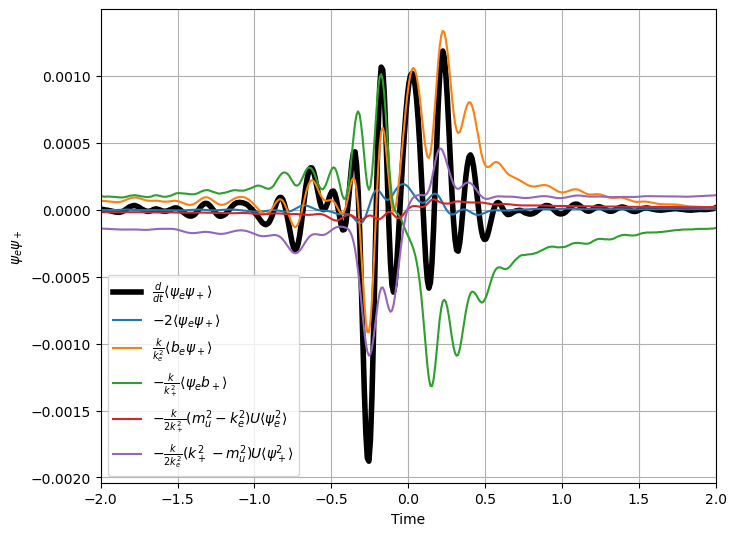

In [83]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Plot all terms with LaTeX-formatted labels
ax.plot(time_array, sumOfIndividualItems, '-k', lw=4, label=r"$\frac{d}{dt} \langle \psi_e \psi_+ \rangle$")
ax.plot(time_array, -2 * average_R / (0.25 * k * (k_plus_square - k_e_square)),
        label=r"$-2 \langle \psi_e \psi_+ \rangle$")
ax.plot(time_array, (k / k_e_square) * average_b_e_psi_plus_list,
        label=r"$\frac{k}{k_e^2} \langle b_e \psi_+ \rangle$")
ax.plot(time_array, (-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list,
        label=r"$-\frac{k}{k_+^2} \langle \psi_e b_+ \rangle$")
ax.plot(time_array, -(k / (2 * k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e),
        label=r"$-\frac{k}{2k_+^2} (m_u^2 - k_e^2) U \langle \psi_e^2 \rangle$")
ax.plot(time_array, -(k / (2 * k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus),
        label=r"$-\frac{k}{2k_e^2} (k_+^2 - m_u^2) U \langle \psi_+^2 \rangle$")

ax.set_xlim(x_limit)
ax.grid(True)
ax.set_xlabel("Time")
ax.set_ylabel(r"$\psi_e \psi_+$")

# Clean legend formatting
ax.legend(loc='best', fontsize=10)

plt.tight_layout(pad=3)
plt.show()

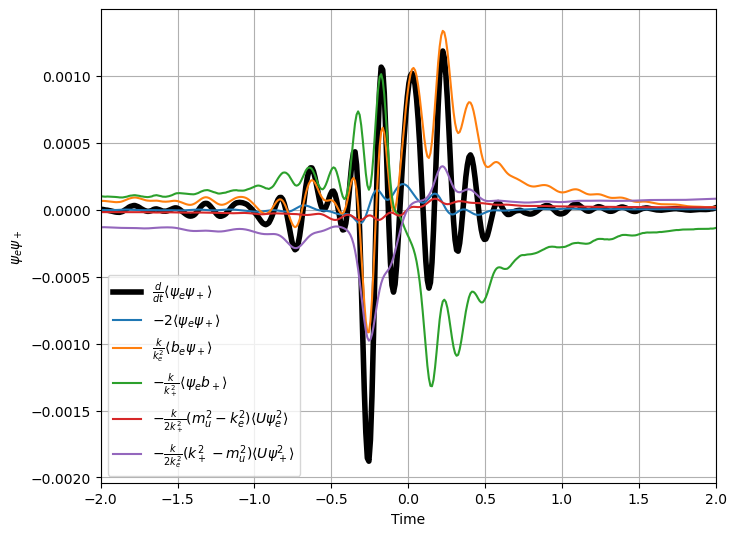

In [84]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Plot all terms with LaTeX-formatted labels
ax.plot(time_array, sumOfIndividualItems, '-k', lw=4, label=r"$\frac{d}{dt} \langle \psi_e \psi_+ \rangle$")
ax.plot(time_array, -2 * average_R / (0.25 * k * (k_plus_square - k_e_square)),
        label=r"$-2 \langle \psi_e \psi_+ \rangle$")
ax.plot(time_array, (k / k_e_square) * average_b_e_psi_plus_list,
        label=r"$\frac{k}{k_e^2} \langle b_e \psi_+ \rangle$")
ax.plot(time_array, (-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list,
        label=r"$-\frac{k}{k_+^2} \langle \psi_e b_+ \rangle$")
ax.plot(time_array, -(k / (2 * k_plus_square) * (m_u ** 2 - k_e_square) * average_U * average_k_e_psi_e_list),
        label=r"$-\frac{k}{2k_+^2} (m_u^2 - k_e^2)  \langle U \psi_e^2 \rangle$")
ax.plot(time_array, -(k / (2 * k_e_square) * (k_plus_square - m_u ** 2) * average_U * average_k_e_psi_plus_list),
        label=r"$-\frac{k}{2k_e^2} (k_+^2 - m_u^2)  \langle U \psi_+^2 \rangle$")

ax.set_xlim(x_limit)
ax.grid(True)
ax.set_xlabel("Time")
ax.set_ylabel(r"$\psi_e \psi_+$")

# Clean legend formatting
ax.legend(loc='best', fontsize=10)

plt.tight_layout(pad=3)
plt.show()